## Climate Data Aggregation and NA County Check Functions

This notebook includes two key functions for validating and visualizing county-level climate data aggregation:

1. **`check_aggregation_correctness()`**  
   - Purpose: Compares raw gridded climate data with aggregated county-level data to verify correctness of the spatial aggregation process.  
   - Outputs:  
     - Number of counties with at least one `NA` in any `order_1` to `order_4` columns  
     - Number of counties remaining after excluding those with `NA`s  
     - Side-by-side plots of raw grid data and aggregated county data with consistent color scales  
   - Usage: Provide folder paths for raw and aggregated data, filename templates with year placeholders, county shapefile path and ID column, and the years of interest.

2. **`plot_na_counties()`**  
   - Purpose: Identifies and visualizes counties with missing (`NA`) values in any of the `order_` columns within aggregated data files.  
   - Outputs:  
     - Plot highlighting NA counties in red with all county boundaries outlined  
     - Returns a set of county IDs containing NA values  
   - Usage: Provide aggregated data folder and filename template, county shapefile and relevant ID columns, years to check, and optionally crop boundaries for the plot.

---

### Example Calls

```python
# Check aggregation correctness for years 2000-2004
check_aggregation_correctness(
    raw_folder="path/to/raw_data",
    agg_folder="path/to/aggregated_data",
    raw_template="raw_{}.tif",
    agg_template="agg_{}.csv",
    shapefile_path="path/to/county_shapefile.shp",
    shapefile_id_col="GEOID",
    years=range(2000, 2005)
)

# Plot counties with missing data and get their IDs
na_counties = plot_na_counties(
    agg_folder="path/to/aggregated_data",
    agg_template="agg_{}.csv",
    shapefile_path="path/to/county_shapefile.shp",
    shapefile_id_col="GEOID",
    agg_id_col="poly_id",
    years=range(2000, 2005),
    crop_bounds=(-125, 24, -66.5, 50)  # Optional mainland USA crop
)
print(f"Counties with missing data: {na_counties}")


## Functions

In [2]:
import os
import pandas as pd
import xarray as xr
import geopandas as gpd
import rioxarray as rxr
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
import glob
from termcolor import cprint



In [3]:
# Add sibling folder to sys.path (for notebooks)
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'y_utils')))

import functions 
import config


In [4]:
def check_files(dir_path, file_format, start_year, end_year):
    years = range(start_year, end_year + 1)
    unique_counties = None

    results = {}
    missing_years = []
    passed_years = []
    failed_years = []

    for year in years:
        file_path = os.path.join(dir_path, f"{file_format}{year}.csv")
        year_result = {
            "file_exists": False,
            "na_values": False,
            "counties_12_months_pct": None,
            "unique_counties": None,
            "order_1_range_pass": None,
            "fail_reasons": []
        }

        if not os.path.isfile(file_path):
            missing_years.append(year)
            results[year] = year_result
            continue

        year_result["file_exists"] = True
        df = pd.read_csv(file_path)

        # Check NA values in any column
        if df.isna().any().any():
            year_result["na_values"] = True
            year_result["fail_reasons"].append("NA values present")

        # Check counties have exactly 12 rows for months 1-12
        months_per_county = df.groupby("poly_id")["month"].nunique()
        counties_with_12_months = months_per_county[months_per_county == 12].count()
        total_counties = months_per_county.count()
        pct_12_months = (counties_with_12_months / total_counties) * 100 if total_counties > 0 else 0
        year_result["counties_12_months_pct"] = pct_12_months

        if pct_12_months < 100:
            year_result["fail_reasons"].append(f"Counties with 12 months data: {pct_12_months:.1f}%")

        # Check unique counties count (only once)
        if unique_counties is None:
            unique_counties = df["poly_id"].nunique()
        year_result["unique_counties"] = unique_counties

        # Check average order_1/30 is in [0, 40]
        avg_order_1 = (df["order_1"] / 30).mean()
        if not (0 <= avg_order_1 <= 40):
            year_result["order_1_range_pass"] = False
            year_result["fail_reasons"].append(f"order_1/30 average out of range ({avg_order_1:.2f})")
        else:
            year_result["order_1_range_pass"] = True

        # Determine if year failed any check
        if year_result["fail_reasons"]:
            failed_years.append(year)
        else:
            passed_years.append(year)

        results[year] = year_result

    # Print summary header
    print("-" * 40)
    print(f"Directory: {dir_path}")
    print(f"File format: {file_format}")
    print(f"Year range: {start_year}-{end_year}")
    print("-" * 40)
    print()

    # Print detailed reports only for failed years and missing years
    for year in years:
        res = results[year]
        if year in missing_years:
            print(f"Year: {year}")
            print("  - File Exists: No")
            print("  - Skipping checks for this year.\n")
        elif year in failed_years:
            print(f"Year: {year}")
            print(f"  - File Exists: Yes")
            print(f"  - NA Values Present: {'Yes' if res['na_values'] else 'No'}")
            print(f"  - Counties with 12 months data: {res['counties_12_months_pct']:.1f}%")
            print(f"  - Unique Counties: {res['unique_counties']}")
            print(f"  - order_1 / 30 range check: {'PASS' if res['order_1_range_pass'] else 'FAIL'}")
            print("  - Issues:")
            for reason in res['fail_reasons']:
                print(f"    * {reason}")
            print()

    # Print summary
    total_files = len(years)
    passed_count = len(passed_years)
    failed_count = len(failed_years)
    missing_count = len(missing_years)

    print("-" * 40)
    print("Summary:")
    print(f"Total files checked: {total_files}")
    print(f"Files passed all checks: {passed_count} ({passed_count / total_files * 100:.1f}%)")
    print(f"Files failed: {failed_count} ({failed_count / total_files * 100:.1f}%)")
    print(f"Files missing: {missing_count} ({missing_count / total_files * 100:.1f}%)\n")

    if failed_count > 0:
        print("Files that failed:")
        for y in failed_years:
            reasons = results[y]['fail_reasons']
            print(f"- {y} ({', '.join(reasons)})")
        print()

    if missing_count > 0:
        print("Files missing:")
        for y in missing_years:
            print(f"- {y}")


In [5]:



def convert_lon_0_360_to_neg180_180(da, lon_name='lon', lat_name='lat'):
    """
    Converts a longitude coordinate from 0–360 to -180–180 for easier geographic plotting,
    with support for custom longitude and latitude names.

    Parameters:
    - da: xarray.DataArray or Dataset
    - lon_name: str, name of the longitude coordinate in the dataset (default 'lon')
    - lat_name: str, name of the latitude coordinate (default 'lat') — included for symmetry but not modified.

    Returns:
    - da: updated DataArray or Dataset with corrected longitude coordinates and sorted by longitude
    """
    if lon_name not in da.coords:
        raise KeyError(f"Longitude coordinate '{lon_name}' not found in dataset. Available coords: {list(da.coords)}")

    lon = da[lon_name]
    lon_new = ((lon + 180) % 360) - 180  # Convert to -180 to 180
    da = da.assign_coords({lon_name: lon_new})
    da = da.sortby(lon_name)
    return da   

def print_colored(message, color='cyan'):
    colors = {
        'red': '\033[91m',
        'green': '\033[92m',
        'yellow': '\033[93m',
        'blue': '\033[94m',
        'magenta': '\033[95m',
        'cyan': '\033[96m',
        'endc': '\033[0m',
    }
    print(f"{colors.get(color, colors['cyan'])}{message}{colors['endc']}")

def check_aggregation_correctness(
    raw_folder, agg_folder,
    raw_template, agg_template,
    shapefile_path, shapefile_id_col,
    years=None,
    order_cols=['order_1', 'order_2', 'order_3', 'order_4'],
    column_to_plot='order_1',
    column_to_plot_avg='order_1_avg',
    raw_var_name='tas',
    plot_vmin=-5,
    plot_vmax=30,
    lon_bounds=(-130, -65),
    lat_bounds=(23, 50),
    lon_column='lon',
    lat_column='lat',
    title = "Aggregation Correctness Check"
):
    print_colored("Step 1: Loading shapefile...", 'yellow')
    usa_counties = gpd.read_file(shapefile_path)
    usa_counties[shapefile_id_col] = usa_counties[shapefile_id_col].astype(int)

    if years is None:
        print_colored("No years provided, detecting years from aggregated data files...", 'yellow')
        files = os.listdir(agg_folder)
        years = []
        for f in files:
            if f.endswith('.csv'):
                import re
                m = re.search(r'(\d{4})', f)
                if m:
                    years.append(int(m.group(1)))
        years = sorted(set(years))
        if not years:
            raise ValueError("No years found in aggregated folder filenames.")
    print_colored(f"Years to process: {years}", 'green')

    print_colored("Step 2: Loading and concatenating aggregated county data...", 'yellow')
    agg_dfs = []
    for yr in years:
        fp = os.path.join(agg_folder, agg_template.format(yr))
        print_colored(f"  Loading aggregated file for year {yr}: {fp}", 'blue')
        df = pd.read_csv(fp)
        df['year'] = yr
        agg_dfs.append(df)
    agg_df = pd.concat(agg_dfs)
    print_colored(f"  Aggregated data loaded with shape {agg_df.shape}", 'green')

    print_colored("Step 3: Checking for NA counties in aggregated data...", 'yellow')
    na_poly_ids = agg_df[agg_df[order_cols].isnull().any(axis=1)]['poly_id'].unique()
    num_na_counties = len(na_poly_ids)
    filtered_df = agg_df[~agg_df['poly_id'].isin(na_poly_ids)]
    remaining_na_counties = filtered_df[filtered_df.isnull().any(axis=1)]['poly_id'].nunique()

    print_colored(f"  1. Counties with NA in any {order_cols}: {num_na_counties}", 'red')
    print_colored(f"  2. NA counties remaining after exclusion: {remaining_na_counties}", 'red')

    print_colored("Step 4: Loading and averaging raw grid data across all years...", 'yellow')
    raw_datasets = []
    for yr in years:
        raw_fp = os.path.join(raw_folder, raw_template.format(yr))
        print_colored(f"  Loading raw file for year {yr}: {raw_fp}", 'blue')
        ext = os.path.splitext(raw_fp)[1].lower()
        if ext in ['.tif', '.tiff']:
            ds = rxr.open_rasterio(raw_fp, masked=True).squeeze()
            if 'time' in ds.dims:
                ds = ds.mean(dim='time', skipna=True)
            elif 'band' in ds.dims:
                ds = ds.mean(dim='band', skipna=True)
            raw_datasets.append(ds)
        elif ext in ['.nc', '.grib']:
            ds = xr.open_dataset(raw_fp)
            if raw_var_name in ds.data_vars:
                da = ds[raw_var_name]
                if 'time' in da.dims:
                    da = da.mean(dim='time', skipna=True)
                raw_datasets.append(da)
            else:
                raise ValueError(f"Variable '{raw_var_name}' not found in {raw_fp}")
        else:
            raise ValueError(f"Unsupported raw data format {ext} for file {raw_fp}")
    raw_stack = xr.concat(raw_datasets, dim='year')
    raw_avg = raw_stack.mean(dim='year', skipna=True)
    if raw_var_name.lower() in [raw_var_name, 'temperature', 'temp'] and raw_avg.max() > 100:
        raw_avg = raw_avg - 273.15
    raw_avg = convert_lon_0_360_to_neg180_180(raw_avg, lon_name=lon_column, lat_name=lat_column)
    print_colored(f"  Raw grid data averaged over years {years[0]}-{years[-1]}", 'green')

    print_colored("Step 5: Averaging aggregated county data across all years...", 'yellow')
    agg_avg_df = filtered_df.groupby('poly_id')[column_to_plot_avg].mean().reset_index()
    merged = usa_counties.merge(agg_avg_df, how='left', left_on=shapefile_id_col, right_on='poly_id')
    print_colored(f"  Aggregated county data averaged for plotting", 'green')

    print("raw data dimensions:")
    print(raw_avg.dims)
    print(raw_avg.shape)

    print(f"x min/max: {raw_avg[lon_column].min().item()}, {raw_avg[lon_column].max().item()}")
    print(f"y min/max: {raw_avg[lat_column].min().item()}, {raw_avg[lat_column].max().item()}")


    print_colored("Step 6: Plotting side-by-side maps...", 'yellow')
    fig, axs = plt.subplots(1, 2, figsize=(18, 9))
    with ProgressBar():
        raw_avg.plot(ax=axs[0], cmap='coolwarm', vmin=plot_vmin, vmax=plot_vmax)
    usa_counties.boundary.plot(ax=axs[0], color='black', linewidth=0.3)
    axs[0].set_title(f"Raw Grid Data Average {years[0]}-{years[-1]}")
    axs[0].set_xlim(lon_bounds)
    axs[0].set_ylim(lat_bounds)
    axs[0].axis('off')

    merged.plot(column=column_to_plot_avg, ax=axs[1], cmap='coolwarm', vmin=plot_vmin, vmax=plot_vmax, legend=True)
    axs[1].set_title(f"Aggregated County Data Average {years[0]}-{years[-1]}")
    axs[1].set_xlim(lon_bounds)
    axs[1].set_ylim(lat_bounds)
    axs[1].axis('off')

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
    print_colored("Done!", 'green')


In [6]:
def plot_na_counties(
    agg_folder,
    agg_template,
    shapefile_path,
    shapefile_id_col="GEOID",
    agg_id_col="poly_id",
    years=range(2000, 2005),
    crop_bounds=None,  # (minx, miny, maxx, maxy), e.g. mainland USA
    title="Counties with NA in 'order_' columns"
):
    # Colored print helper
    def cprint(msg, color_code="32"):  # default green
        print(f"\033[{color_code}m{msg}\033[0m")

    cprint("[1/4] Loading shapefile...", "34")
    counties = gpd.read_file(shapefile_path)
    counties[shapefile_id_col] = counties[shapefile_id_col].astype(int)

    cprint("[2/4] Checking CSVs for NA counties...", "34")
    na_fips_set = set()
    order_cols = None

    for year in years:
        path = os.path.join(agg_folder, agg_template.format(year))
        if not os.path.isfile(path):
            cprint(f"Warning: File not found: {path}", "33")
            continue
        df = pd.read_csv(path)
        df[agg_id_col] = df[agg_id_col].astype(int)

        if order_cols is None:
            order_cols = [col for col in df.columns if col.startswith("order_")]
            if not order_cols:
                raise ValueError("No columns starting with 'order_' found in CSV.")

        has_na = df[order_cols].isna().any(axis=1)
        na_fips = df.loc[has_na, agg_id_col].unique()
        na_fips_set.update(na_fips)
        cprint(f"    Year {year}: {len(na_fips)} counties with NA in order_ columns", "35")

        missing_ids = set(counties[shapefile_id_col].unique()) - set(df[agg_id_col].unique())
        na_fips_set.update(missing_ids)
        cprint(f"    Year {year}: {len(missing_ids)} counties missing entirely from CSV", "35")

    cprint(f"[3/4] Found {len(na_fips_set)} unique counties with NAs or missing data in 'order_' columns.", "32")

    cprint("[4/4] Plotting NA counties...", "34")
    na_counties = counties[counties[shapefile_id_col].isin(na_fips_set)]

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Plot all counties boundaries first (no fill, gray thin lines)
    counties.boundary.plot(ax=ax, color="gray", linewidth=0.3)

    # Plot NA counties filled red on top
    na_counties.plot(ax=ax, color="red")

    # Optionally crop bounds
    if crop_bounds is not None:
        minx, miny, maxx, maxy = crop_bounds
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)

    ax.set_title(title)
    ax.axis("off")
    plt.show()

    return na_fips_set


## Basic Checks

In [ ]:

# Example usage:
check_files("/global/scratch/users/yougsanghvi/aggregated_results_era5_usa", "era5_usa_agg_", 1979, 1985)

## Plotting

### ERA5 Checks

Step 1: Loading shapefile...
Years to process: range(1979, 2005)
Step 2: Loading and concatenating aggregated county data...
  Loading aggregated file for year 1979: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/MIROC6/gdnat_usa_agg_MIROC6_1979.csv
  Loading aggregated file for year 1980: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/MIROC6/gdnat_usa_agg_MIROC6_1980.csv
  Loading aggregated file for year 1981: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/MIROC6/gdnat_usa_agg_MIROC6_1981.csv
  Loading aggregated file for year 1982: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/MIROC6/gdnat_usa_agg_MIROC6_1982.csv
  Loading aggregated file for year 1983: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_coun

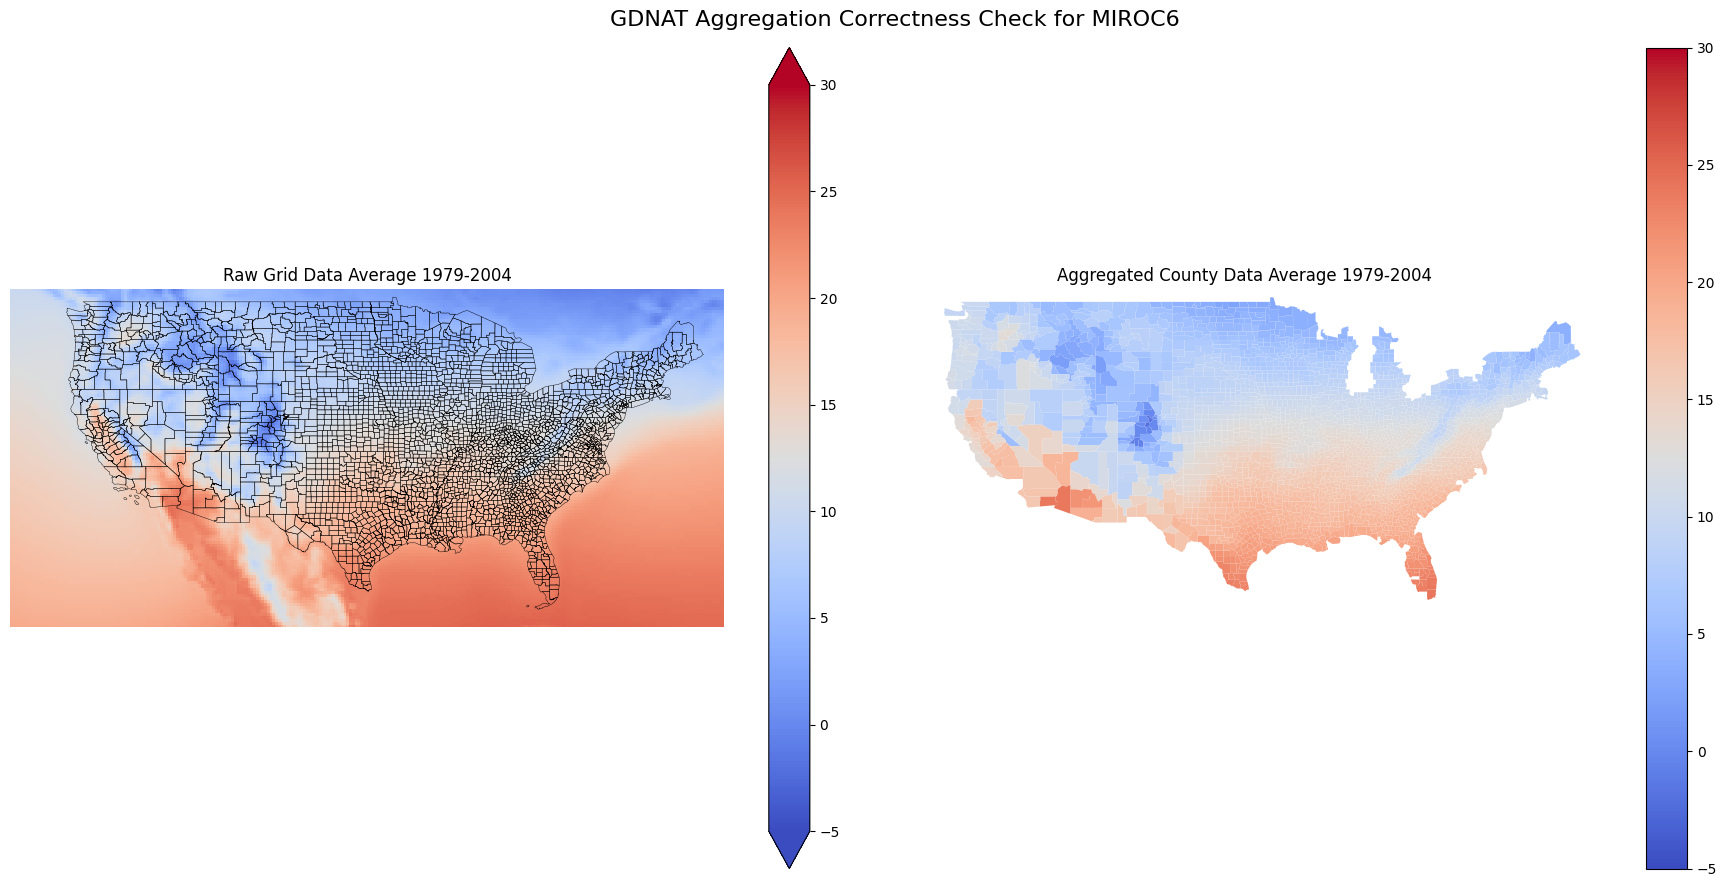

Done!
Step 1: Loading shapefile...
Years to process: range(1979, 2005)
Step 2: Loading and concatenating aggregated county data...
  Loading aggregated file for year 1979: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/ACCESS-ESM1-5/gdnat_usa_agg_ACCESS-ESM1-5_1979.csv
  Loading aggregated file for year 1980: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/ACCESS-ESM1-5/gdnat_usa_agg_ACCESS-ESM1-5_1980.csv
  Loading aggregated file for year 1981: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/ACCESS-ESM1-5/gdnat_usa_agg_ACCESS-ESM1-5_1981.csv
  Loading aggregated file for year 1982: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/ACCESS-ESM1-5/gdnat_usa_agg_ACCESS-ESM1-5_1982.csv
  Loading aggregated file for year 1983: /global/scratch/projects/co_carleton/car

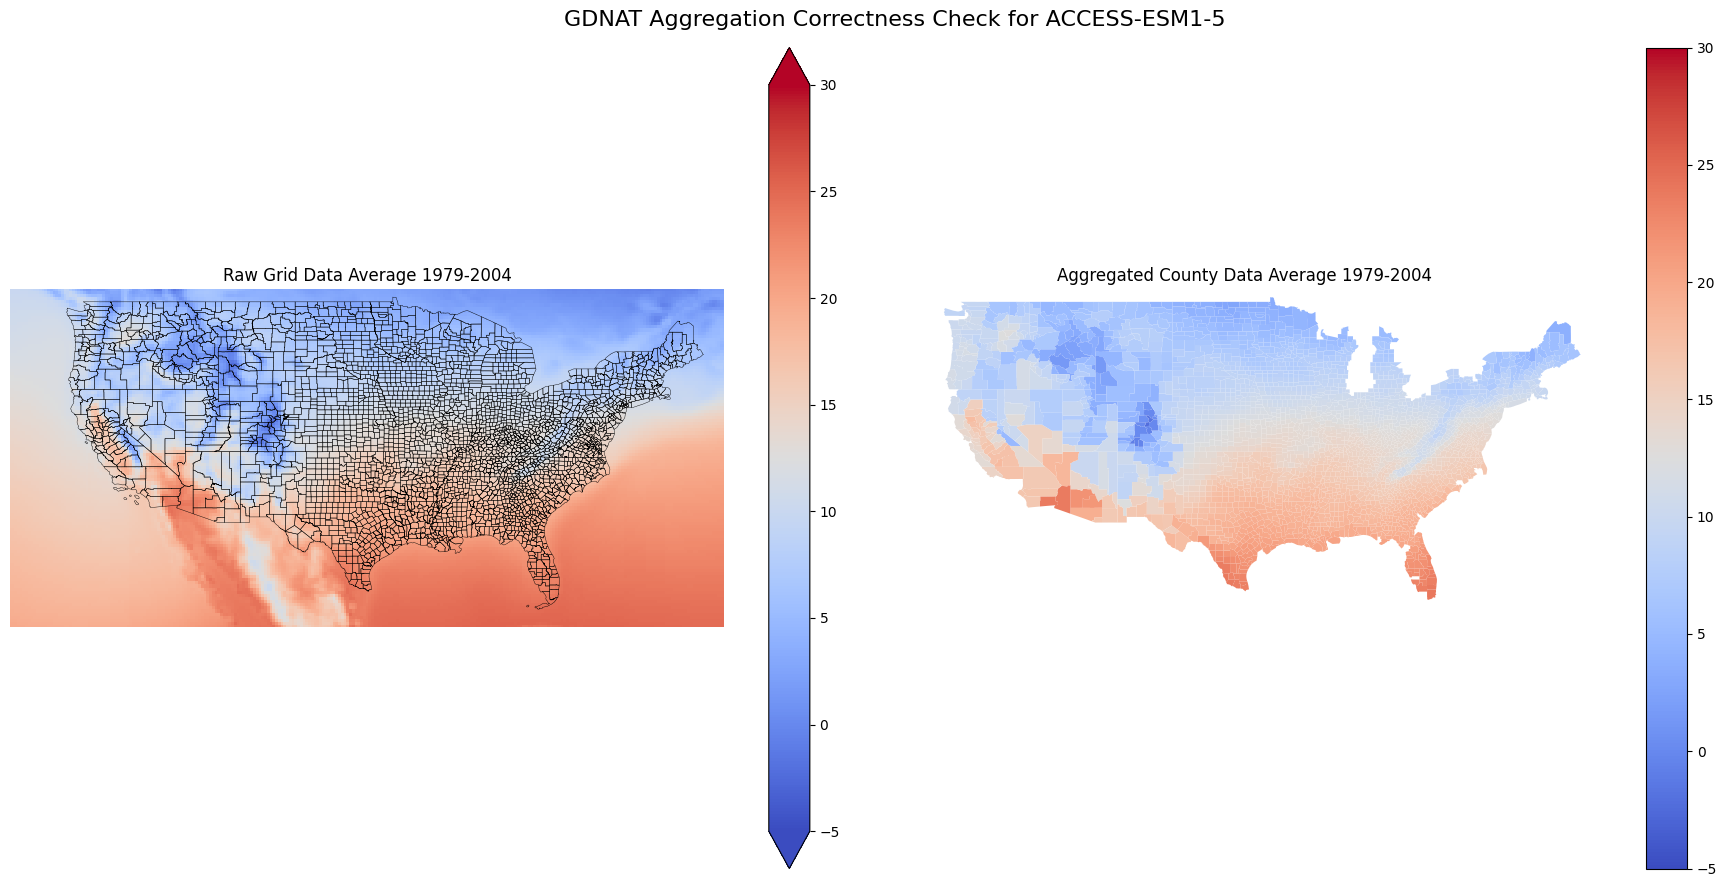

Done!
Step 1: Loading shapefile...
Years to process: range(1979, 2005)
Step 2: Loading and concatenating aggregated county data...
  Loading aggregated file for year 1979: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/CanESM5/gdnat_usa_agg_CanESM5_1979.csv
  Loading aggregated file for year 1980: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/CanESM5/gdnat_usa_agg_CanESM5_1980.csv
  Loading aggregated file for year 1981: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/CanESM5/gdnat_usa_agg_CanESM5_1981.csv
  Loading aggregated file for year 1982: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/CanESM5/gdnat_usa_agg_CanESM5_1982.csv
  Loading aggregated file for year 1983: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregate

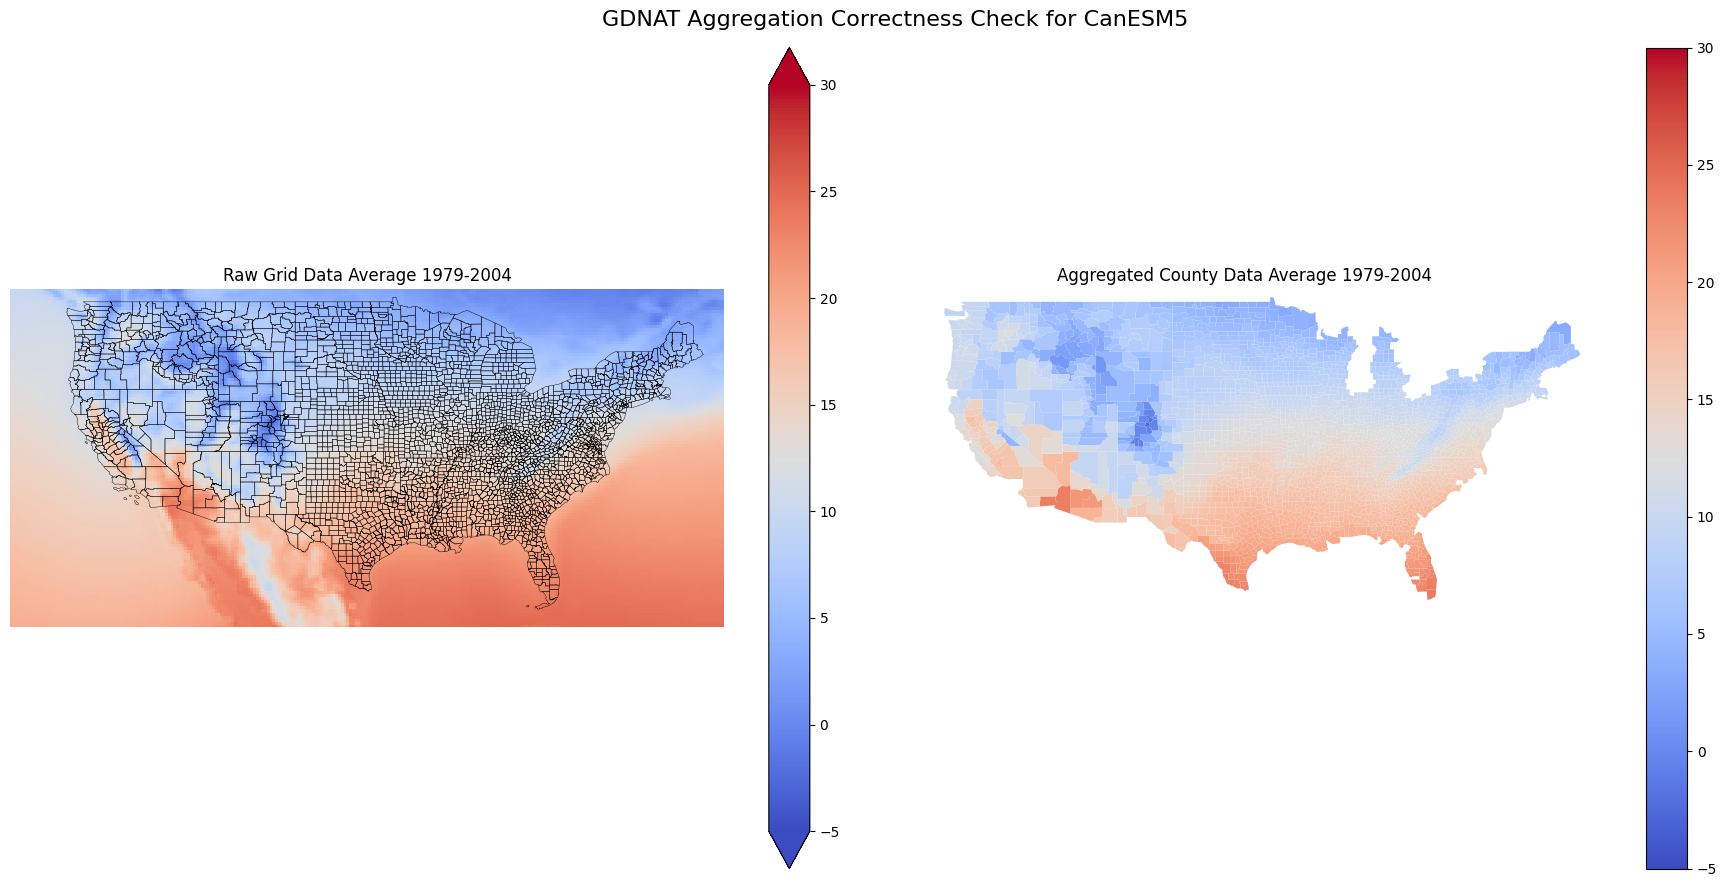

Done!
Step 1: Loading shapefile...
Years to process: range(1979, 2005)
Step 2: Loading and concatenating aggregated county data...
  Loading aggregated file for year 1979: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/MRI-ESM2-0/gdnat_usa_agg_MRI-ESM2-0_1979.csv
  Loading aggregated file for year 1980: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/MRI-ESM2-0/gdnat_usa_agg_MRI-ESM2-0_1980.csv
  Loading aggregated file for year 1981: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/MRI-ESM2-0/gdnat_usa_agg_MRI-ESM2-0_1981.csv
  Loading aggregated file for year 1982: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/MRI-ESM2-0/gdnat_usa_agg_MRI-ESM2-0_1982.csv
  Loading aggregated file for year 1983: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_a

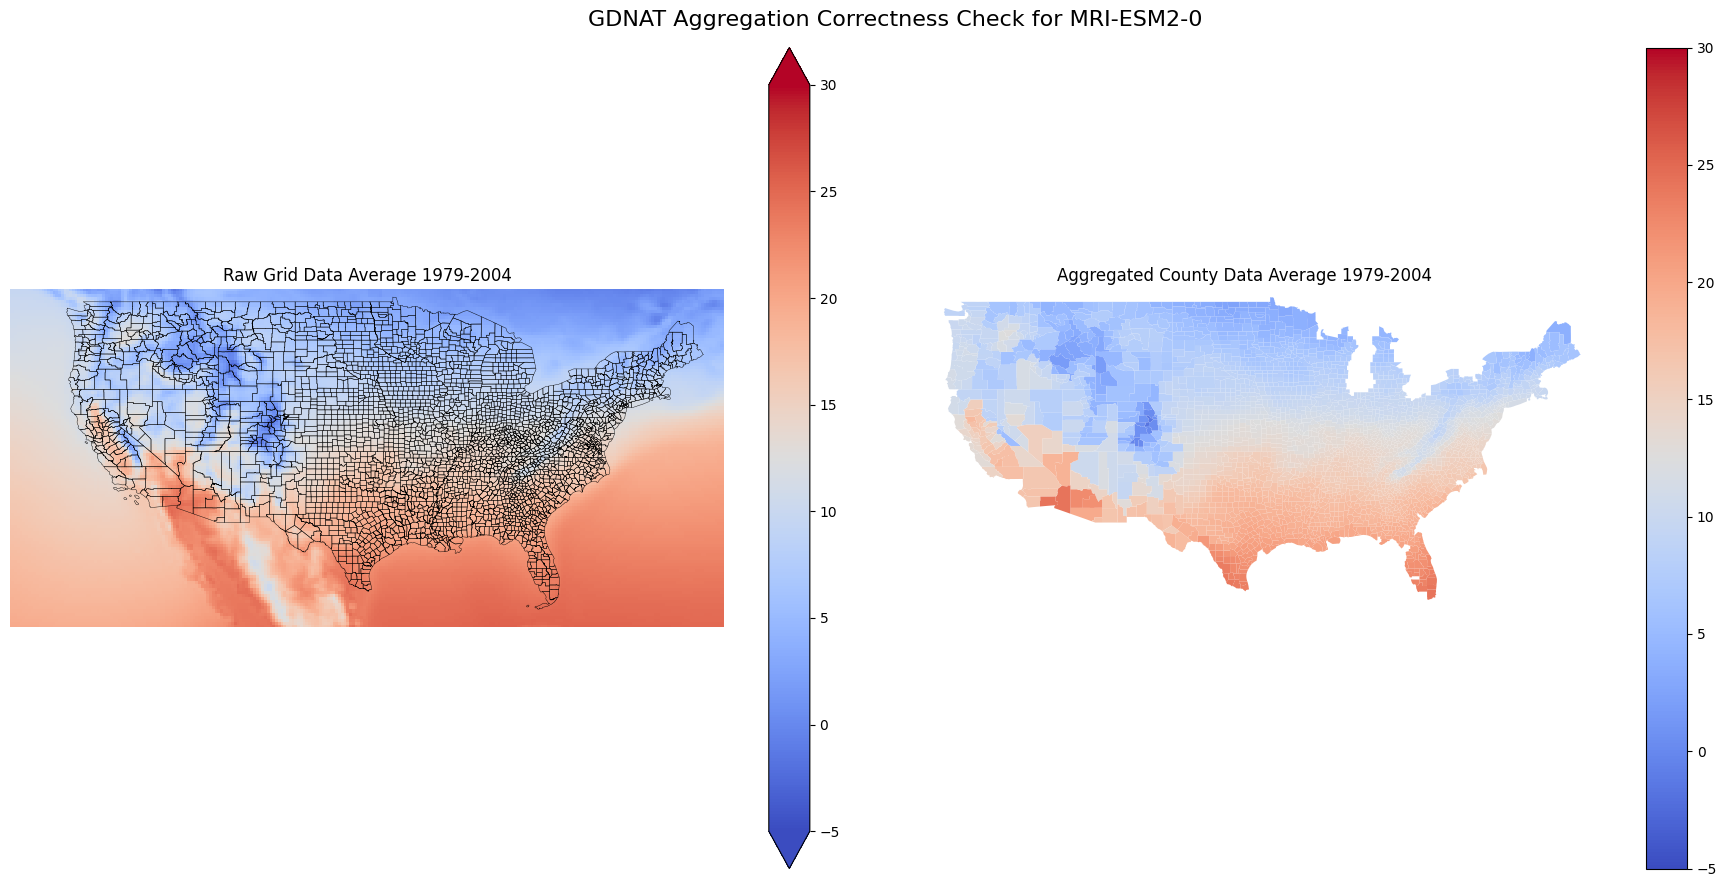

Done!
Step 1: Loading shapefile...
Years to process: range(1979, 2005)
Step 2: Loading and concatenating aggregated county data...
  Loading aggregated file for year 1979: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/NorESM2-LM/gdnat_usa_agg_NorESM2-LM_1979.csv
  Loading aggregated file for year 1980: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/NorESM2-LM/gdnat_usa_agg_NorESM2-LM_1980.csv
  Loading aggregated file for year 1981: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/NorESM2-LM/gdnat_usa_agg_NorESM2-LM_1981.csv
  Loading aggregated file for year 1982: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/NorESM2-LM/gdnat_usa_agg_NorESM2-LM_1982.csv
  Loading aggregated file for year 1983: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_a

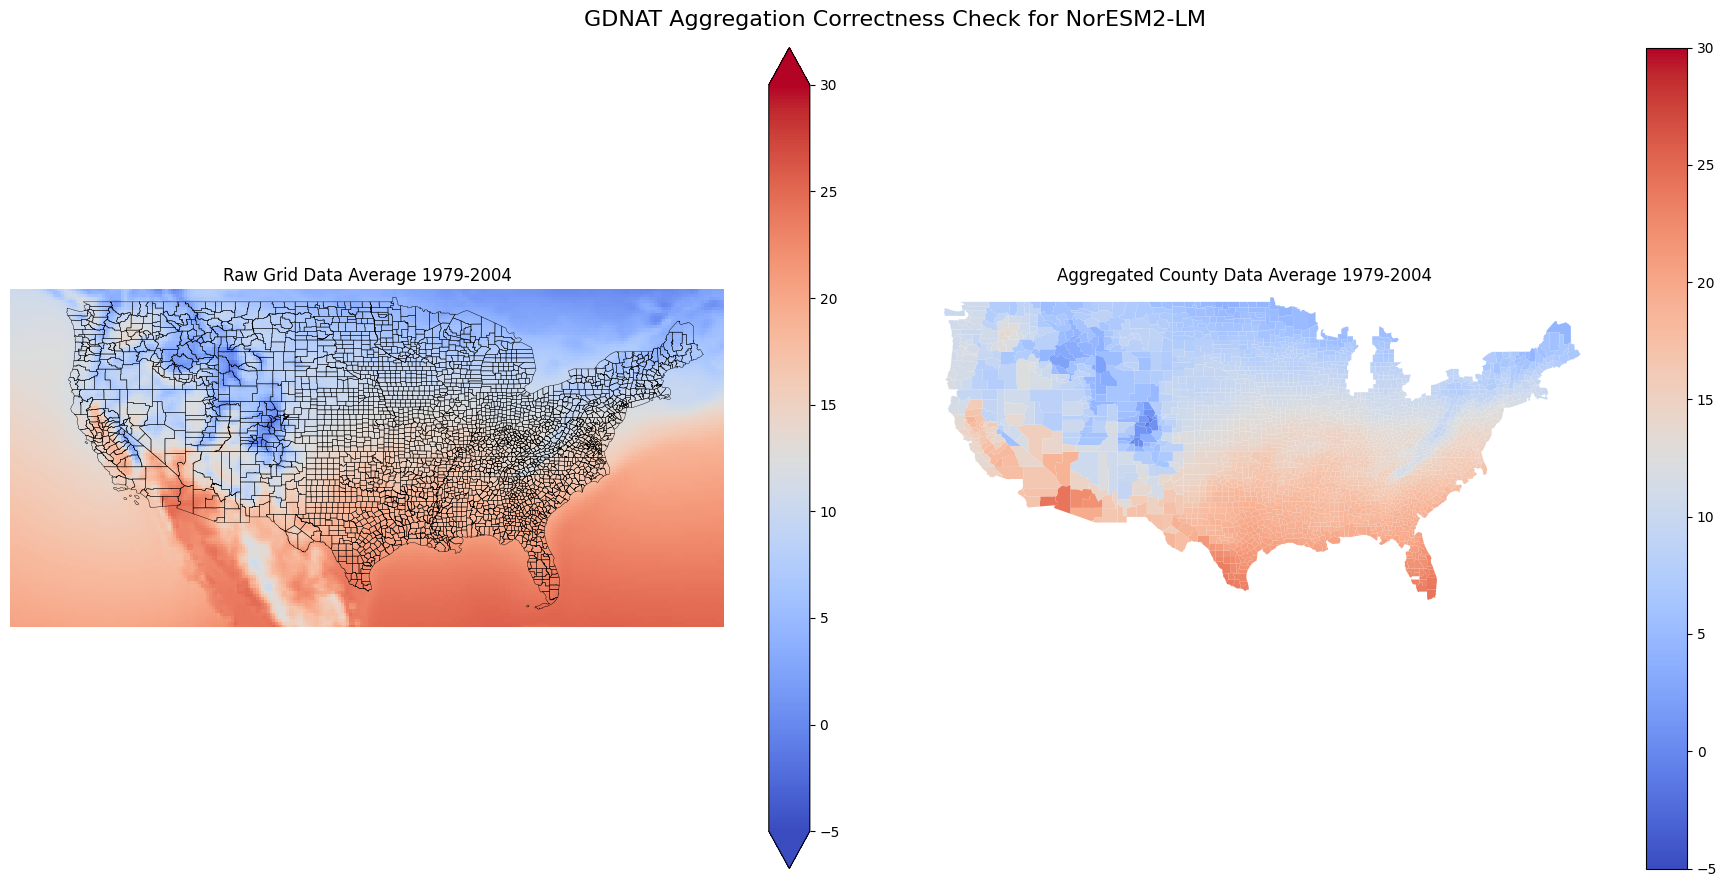

Done!
Step 1: Loading shapefile...
Years to process: range(1979, 2005)
Step 2: Loading and concatenating aggregated county data...
  Loading aggregated file for year 1979: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/ACCESS-CM2/gdnat_usa_agg_ACCESS-CM2_1979.csv
  Loading aggregated file for year 1980: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/ACCESS-CM2/gdnat_usa_agg_ACCESS-CM2_1980.csv
  Loading aggregated file for year 1981: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/ACCESS-CM2/gdnat_usa_agg_ACCESS-CM2_1981.csv
  Loading aggregated file for year 1982: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_allmodels_Jul24/aggregated/usa_pop_county/ACCESS-CM2/gdnat_usa_agg_ACCESS-CM2_1982.csv
  Loading aggregated file for year 1983: /global/scratch/projects/co_carleton/carleton_colab/data/gdnat_a

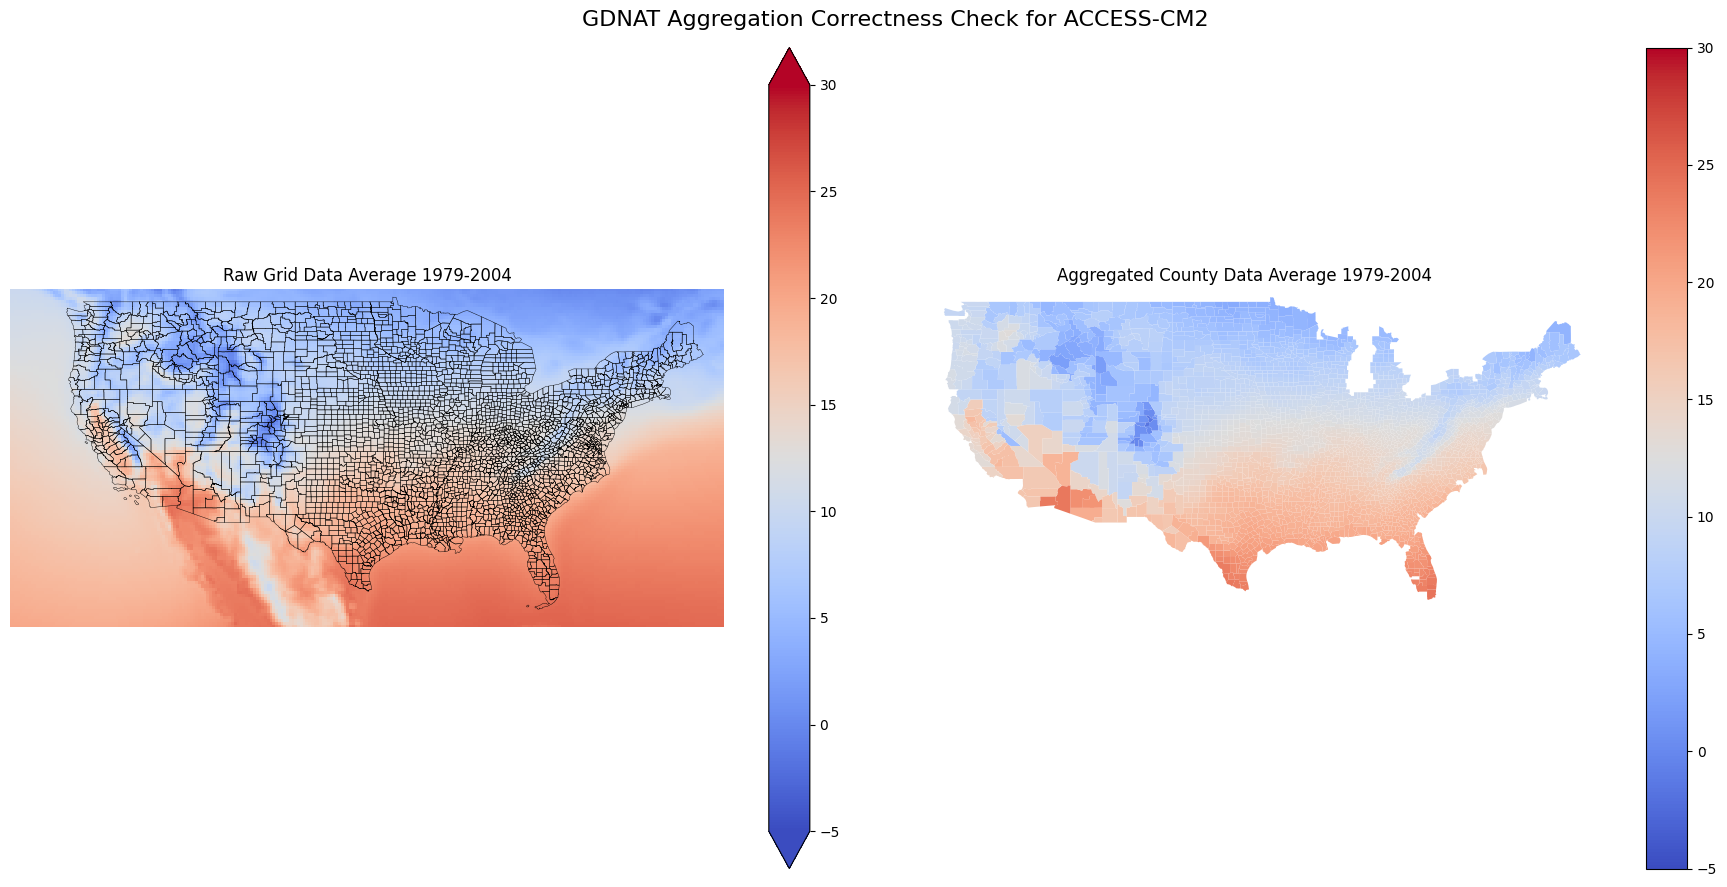

Done!


In [ ]:
# misplaced gdnat check

models = ["MIROC6", "ACCESS-ESM1-5", "CanESM5", "MRI-ESM2-0", "NorESM2-LM", "ACCESS-CM2"]
for model in models:
    check_aggregation_correctness(
        raw_folder=os.path.join(config.GDNAT_TIFF_OUTPUT_DIR, model),
        agg_folder=os.path.join(config.GDNAT_USA_AGG_ALL_MODELS_FP, model),
        raw_template="gdnat_{}.tif",
        agg_template=f"gdnat_usa_agg_{model}_{{}}.csv",  # year will be formatted later
        shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
        shapefile_id_col="GEOID",
        years=range(1979, 2005),
        raw_var_name='tas',
        lon_column='x',
        lat_column='y',
        title =f"GDNAT Aggregation Correctness Check for {model}"
    )


Step 1: Loading shapefile...
Years to process: range(1979, 2005)
Step 2: Loading and concatenating aggregated county data...
  Loading aggregated file for year 1979: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1979.csv
  Loading aggregated file for year 1980: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1980.csv
  Loading aggregated file for year 1981: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1981.csv
  Loading aggregated file for year 1982: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1982.csv
  Loading aggregated file for year 1983: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1983.csv
  Loading aggregated file for year 1984: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1984.csv
  Loading aggregated file for year 1985: /global/scratch/users/yougsanghvi/aggregated_results_era5_usa/era5_usa_agg_1985.csv


/tmp/ipykernel_768859/1304084558.py:105: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(raw_fp)


  Loading raw file for year 1980: /global/scratch/users/yougsanghvi/era5_daily_by_year/era5_daily_mean_1980.nc


/tmp/ipykernel_768859/1304084558.py:105: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(raw_fp)


  Loading raw file for year 1981: /global/scratch/users/yougsanghvi/era5_daily_by_year/era5_daily_mean_1981.nc


...

  Loading raw file for year 2003: /global/scratch/users/yougsanghvi/era5_daily_by_year/era5_daily_mean_2003.nc


/tmp/ipykernel_768859/1304084558.py:105: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(raw_fp)


  Loading raw file for year 2004: /global/scratch/users/yougsanghvi/era5_daily_by_year/era5_daily_mean_2004.nc


/tmp/ipykernel_768859/1304084558.py:105: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(raw_fp)


  Raw grid data averaged over years 1979-2004
Step 5: Averaging aggregated county data across all years...
  Aggregated county data averaged for plotting
raw data dimensions:
('latitude', 'longitude')
(721, 1440)
x min/max: -180.0, 179.75
y min/max: -90.0, 90.0
Step 6: Plotting side-by-side maps...


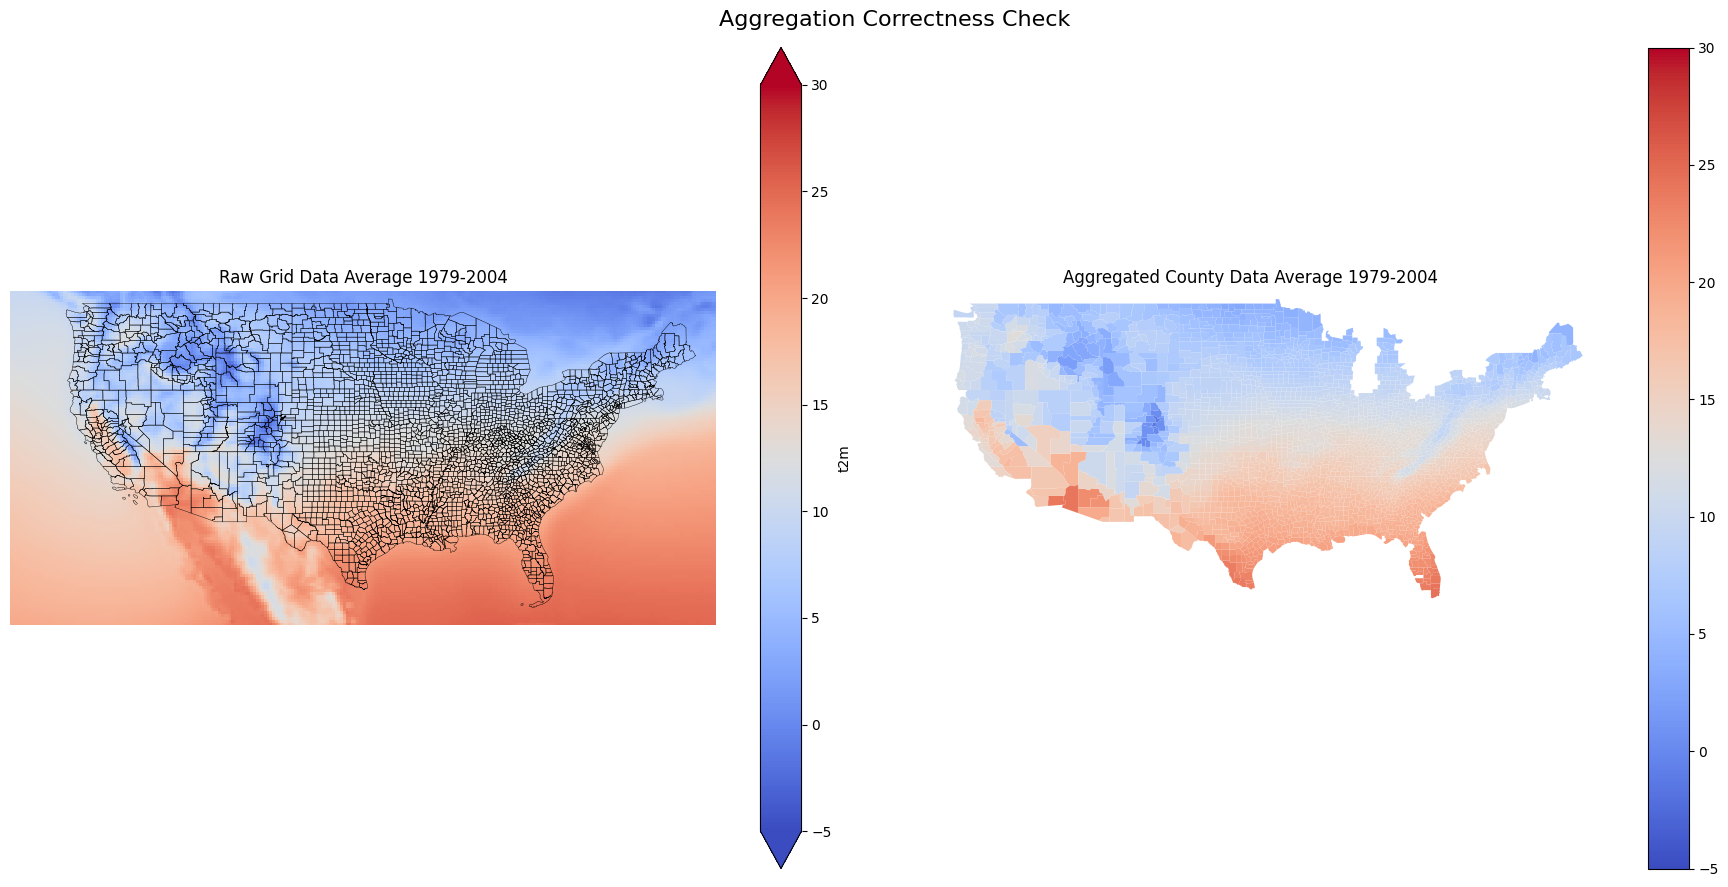

Done!


In [29]:
check_aggregation_correctness(
    raw_folder="/global/scratch/users/yougsanghvi/era5_daily_by_year",
    agg_folder="/global/scratch/users/yougsanghvi/aggregated_results_era5_usa",
    raw_template="era5_daily_mean_{}.nc",
    agg_template="era5_usa_agg_{}.csv",
    shapefile_path="/global/scratch/users/yougsanghvi/shapefiles/tl_2016_us_county_mortality.shp",
    shapefile_id_col="GEOID",
    years=range(1979, 2005),
    raw_var_name = 't2m',
    lon_column='longitude',
    lat_column='latitude',
)

[1/4] Loading shapefile...
[2/4] Checking CSVs for NA counties...
    Year 1979: 97 counties with NA in order_ columns
    Year 1979: 0 counties missing entirely from CSV
    Year 1980: 97 counties with NA in order_ columns
    Year 1980: 0 counties missing entirely from CSV
    Year 1981: 97 counties with NA in order_ columns
    Year 1981: 0 counties missing entirely from CSV
    Year 1982: 97 counties with NA in order_ columns
    Year 1982: 0 counties missing entirely from CSV
    Year 1983: 97 counties with NA in order_ columns
    Year 1983: 0 counties missing entirely from CSV
    Year 1984: 97 counties with NA in order_ columns
    Year 1984: 0 counties missing entirely from CSV
    Year 1985: 97 counties with NA in order_ columns
    Year 1985: 0 counties missing entirely from CSV
    Year 1986: 97 counties with NA in order_ columns
    Year 1986: 0 counties missing entirely from CSV
    Year 1987: 97 counties with NA in order_ columns
    Year 1987: 0 counties missing entirel

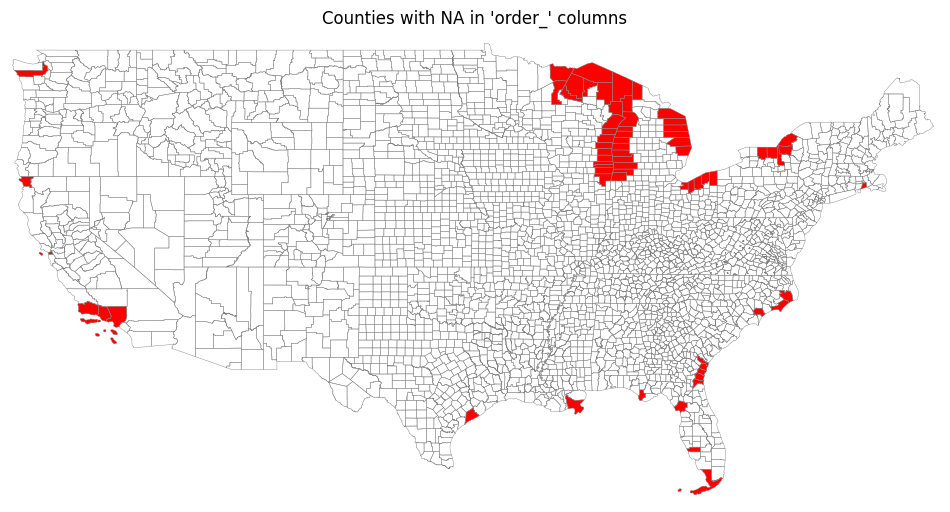

In [31]:
na_fips = plot_na_counties(
    agg_folder="/global/scratch/users/yougsanghvi/aggregated_results_era5_usa",
    agg_template="era5_usa_agg_{}.csv",
    shapefile_path="/global/scratch/users/yougsanghvi/shapefiles/tl_2016_us_county_mortality.shp",
    shapefile_id_col="GEOID",
    years=range(1979, 2004),
    crop_bounds=(-125, 24, -66.5, 50)  # mainland USA approx bounds
)


### GDNat Checks

In [ ]:
models = ["MIROC6", "ACCESS-ESM1-5", "CanESM5", "MRI-ESM2-0", "NorESM2-LM", "ACCESS-CM2"]

for model in models:
    check_aggregation_correctness(
        raw_folder=os.path.join(config.GDNAT_TIFF_OUTPUT_DIR, model),
        agg_folder=os.path.join(config.GDNAT_USA_AGG_ALL_MODELS_FP, model),
        raw_template="gdnat_{}.tif",
        agg_template=f"gdnat_usa_agg_{model}_{{}}.csv",  # year will be formatted later
        shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
        shapefile_id_col="GEOID",
        years=range(1979, 2005),
        raw_var_name='tas',
        lon_column='x',
        lat_column='y',
        title =f"GDNAT Aggregation Correctness Check for {model}"
    )


[1/4] Loading shapefile...
[2/4] Checking CSVs for NA counties...
    Year 1979: 97 counties with NA in order_ columns
    Year 1979: 0 counties missing entirely from CSV
    Year 1980: 97 counties with NA in order_ columns
    Year 1980: 0 counties missing entirely from CSV
    Year 1981: 97 counties with NA in order_ columns
    Year 1981: 0 counties missing entirely from CSV
    Year 1982: 97 counties with NA in order_ columns
    Year 1982: 0 counties missing entirely from CSV
    Year 1983: 97 counties with NA in order_ columns
    Year 1983: 0 counties missing entirely from CSV
    Year 1984: 97 counties with NA in order_ columns
    Year 1984: 0 counties missing entirely from CSV
    Year 1985: 97 counties with NA in order_ columns
    Year 1985: 0 counties missing entirely from CSV
    Year 1986: 97 counties with NA in order_ columns
    Year 1986: 0 counties missing entirely from CSV
    Year 1987: 97 counties with NA in order_ columns
    Year 1987: 0 counties missing entirel

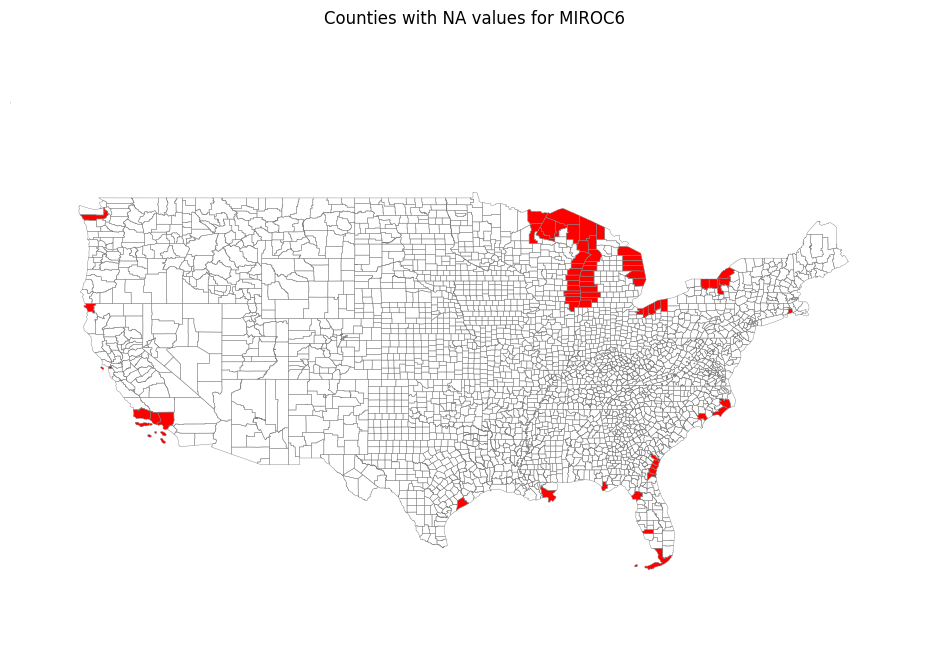

[1/4] Loading shapefile...
[2/4] Checking CSVs for NA counties...
    Year 1979: 97 counties with NA in order_ columns
    Year 1979: 0 counties missing entirely from CSV
    Year 1980: 97 counties with NA in order_ columns
    Year 1980: 0 counties missing entirely from CSV
    Year 1981: 97 counties with NA in order_ columns
    Year 1981: 0 counties missing entirely from CSV
    Year 1982: 97 counties with NA in order_ columns
    Year 1982: 0 counties missing entirely from CSV
    Year 1983: 97 counties with NA in order_ columns
    Year 1983: 0 counties missing entirely from CSV
    Year 1984: 97 counties with NA in order_ columns
    Year 1984: 0 counties missing entirely from CSV
    Year 1985: 97 counties with NA in order_ columns
    Year 1985: 0 counties missing entirely from CSV
    Year 1986: 97 counties with NA in order_ columns
    Year 1986: 0 counties missing entirely from CSV
    Year 1987: 97 counties with NA in order_ columns
    Year 1987: 0 counties missing entirel

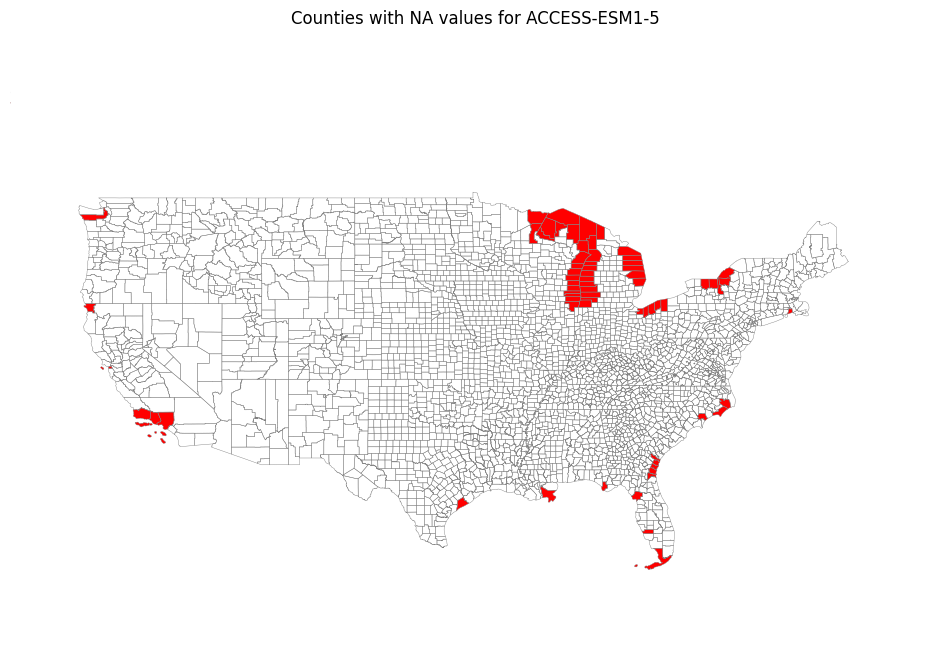

[1/4] Loading shapefile...
[2/4] Checking CSVs for NA counties...
    Year 1979: 97 counties with NA in order_ columns
    Year 1979: 0 counties missing entirely from CSV
    Year 1980: 97 counties with NA in order_ columns
    Year 1980: 0 counties missing entirely from CSV
    Year 1981: 97 counties with NA in order_ columns
    Year 1981: 0 counties missing entirely from CSV
    Year 1982: 97 counties with NA in order_ columns
    Year 1982: 0 counties missing entirely from CSV
    Year 1983: 97 counties with NA in order_ columns
    Year 1983: 0 counties missing entirely from CSV
    Year 1984: 97 counties with NA in order_ columns
    Year 1984: 0 counties missing entirely from CSV
    Year 1985: 97 counties with NA in order_ columns
    Year 1985: 0 counties missing entirely from CSV
    Year 1986: 97 counties with NA in order_ columns
    Year 1986: 0 counties missing entirely from CSV
    Year 1987: 97 counties with NA in order_ columns
    Year 1987: 0 counties missing entirel

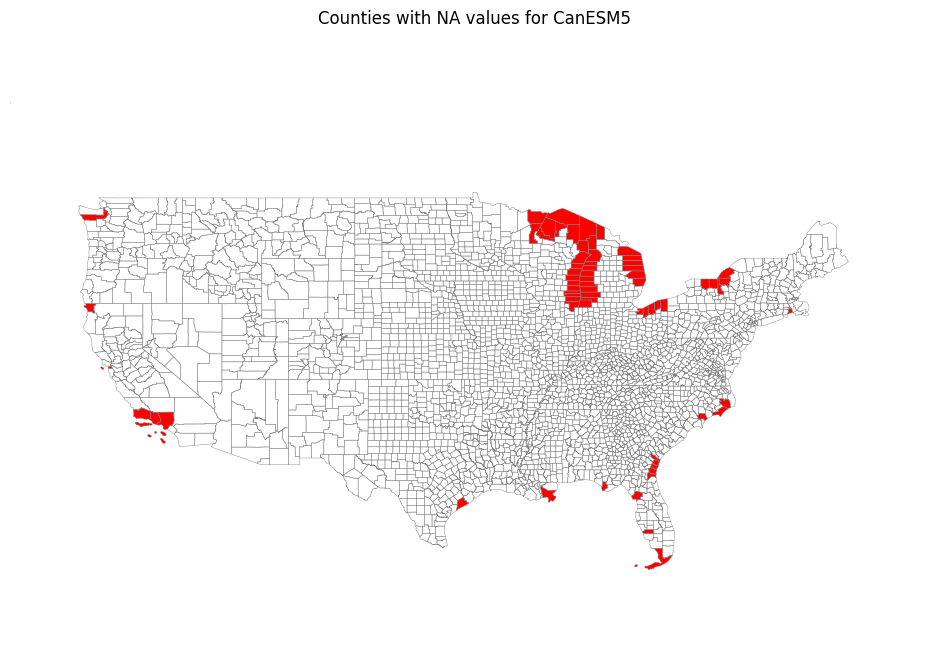

[1/4] Loading shapefile...
[2/4] Checking CSVs for NA counties...
    Year 1979: 97 counties with NA in order_ columns
    Year 1979: 0 counties missing entirely from CSV
    Year 1980: 97 counties with NA in order_ columns
    Year 1980: 0 counties missing entirely from CSV
    Year 1981: 97 counties with NA in order_ columns
    Year 1981: 0 counties missing entirely from CSV
    Year 1982: 97 counties with NA in order_ columns
    Year 1982: 0 counties missing entirely from CSV
    Year 1983: 97 counties with NA in order_ columns
    Year 1983: 0 counties missing entirely from CSV
    Year 1984: 97 counties with NA in order_ columns
    Year 1984: 0 counties missing entirely from CSV
    Year 1985: 97 counties with NA in order_ columns
    Year 1985: 0 counties missing entirely from CSV
    Year 1986: 97 counties with NA in order_ columns
    Year 1986: 0 counties missing entirely from CSV
    Year 1987: 97 counties with NA in order_ columns
    Year 1987: 0 counties missing entirel

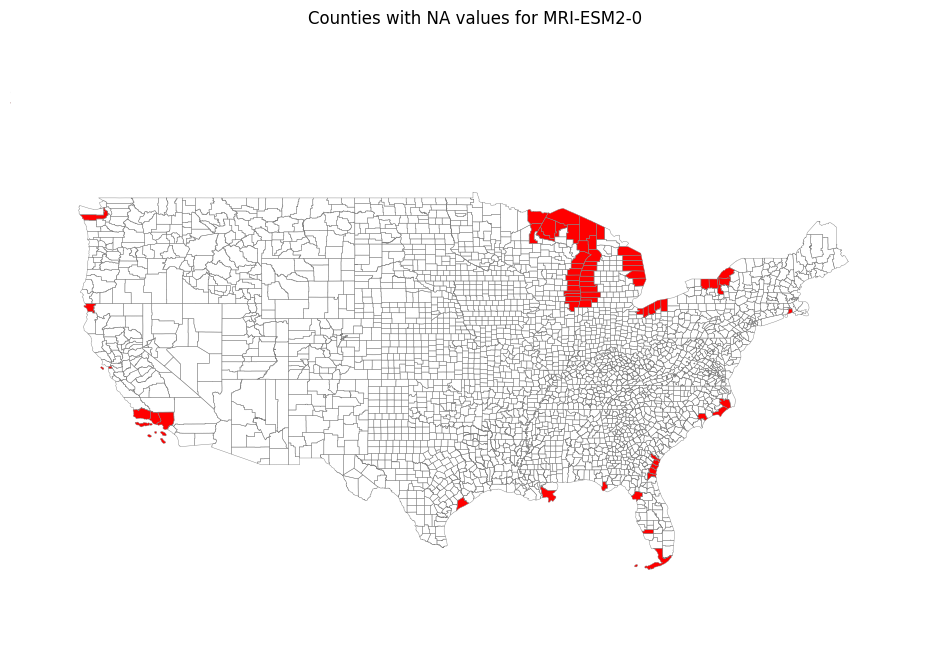

[1/4] Loading shapefile...
[2/4] Checking CSVs for NA counties...
    Year 1979: 97 counties with NA in order_ columns
    Year 1979: 0 counties missing entirely from CSV
    Year 1980: 97 counties with NA in order_ columns
    Year 1980: 0 counties missing entirely from CSV
    Year 1981: 97 counties with NA in order_ columns
    Year 1981: 0 counties missing entirely from CSV
    Year 1982: 97 counties with NA in order_ columns
    Year 1982: 0 counties missing entirely from CSV
    Year 1983: 97 counties with NA in order_ columns
    Year 1983: 0 counties missing entirely from CSV
    Year 1984: 97 counties with NA in order_ columns
    Year 1984: 0 counties missing entirely from CSV
    Year 1985: 97 counties with NA in order_ columns
    Year 1985: 0 counties missing entirely from CSV
    Year 1986: 97 counties with NA in order_ columns
    Year 1986: 0 counties missing entirely from CSV
    Year 1987: 97 counties with NA in order_ columns
    Year 1987: 0 counties missing entirel

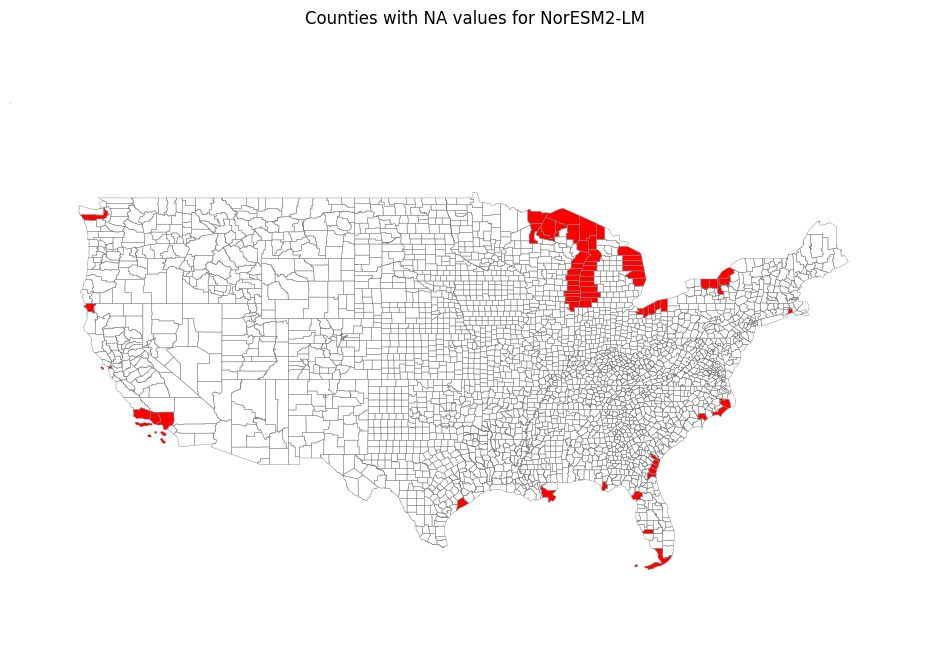

[1/4] Loading shapefile...
[2/4] Checking CSVs for NA counties...
    Year 1979: 97 counties with NA in order_ columns
    Year 1979: 0 counties missing entirely from CSV
    Year 1980: 97 counties with NA in order_ columns
    Year 1980: 0 counties missing entirely from CSV
    Year 1981: 97 counties with NA in order_ columns
    Year 1981: 0 counties missing entirely from CSV
    Year 1982: 97 counties with NA in order_ columns
    Year 1982: 0 counties missing entirely from CSV
    Year 1983: 97 counties with NA in order_ columns
    Year 1983: 0 counties missing entirely from CSV
    Year 1984: 97 counties with NA in order_ columns
    Year 1984: 0 counties missing entirely from CSV
    Year 1985: 97 counties with NA in order_ columns
    Year 1985: 0 counties missing entirely from CSV
    Year 1986: 97 counties with NA in order_ columns
    Year 1986: 0 counties missing entirely from CSV
    Year 1987: 97 counties with NA in order_ columns
    Year 1987: 0 counties missing entirel

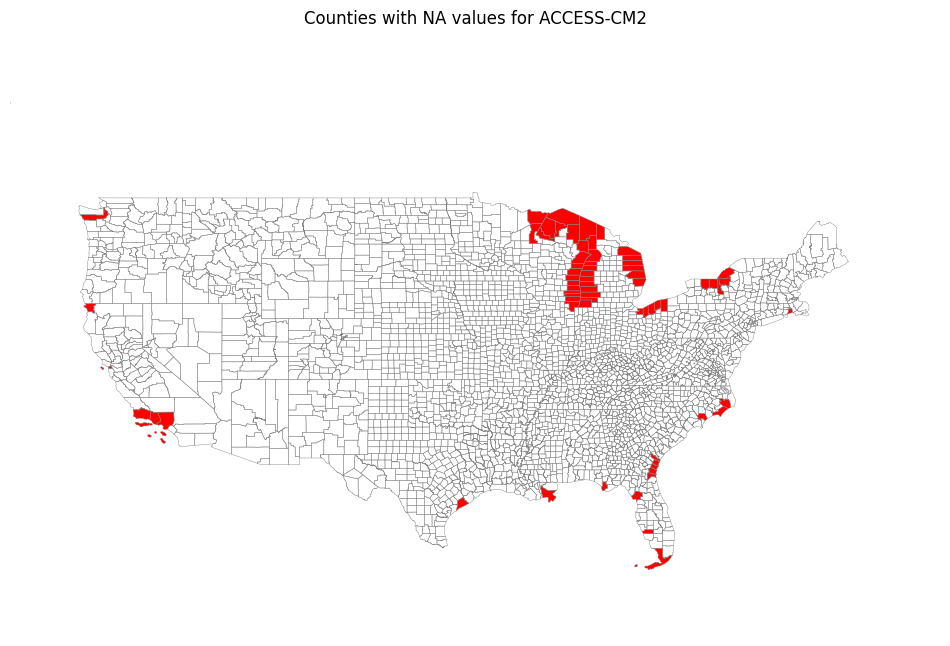

In [23]:
models = ["MIROC6", "ACCESS-ESM1-5", "CanESM5", "MRI-ESM2-0", "NorESM2-LM", "ACCESS-CM2"]

for model in models:
    plot_na_counties(
        agg_folder=os.path.join(config.GDNAT_USA_AGG_ALL_MODELS_FP, model),
        agg_template=f"gdnat_usa_agg_{model}_{{}}.csv",
        shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
        shapefile_id_col="GEOID",
        years=range(1979, 2005),
        crop_bounds=(-130, 20, -60, 60),  # mainland USA approx bounds
        title=f"Counties with NA values for {model}"
    )


Step 1: Loading shapefile...
Years to process: range(2000, 2005)
Step 2: Loading and concatenating aggregated county data...
  Loading aggregated file for year 2000: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2000.csv
  Loading aggregated file for year 2001: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2001.csv
  Loading aggregated file for year 2002: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2002.csv
  Loading aggregated file for year 2003: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2003.csv
  Loading aggregated file for year 2004: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2004.csv
  Aggregated data loaded with shape (193690, 11)
Step 3: Checking for NA counties in aggregated data...
  1. Counties with NA in any ['order_1', 'order_2', 'order_3', 'order_4']: 97
  2. NA counties remaining after exclusion: 0
Step 4: Load

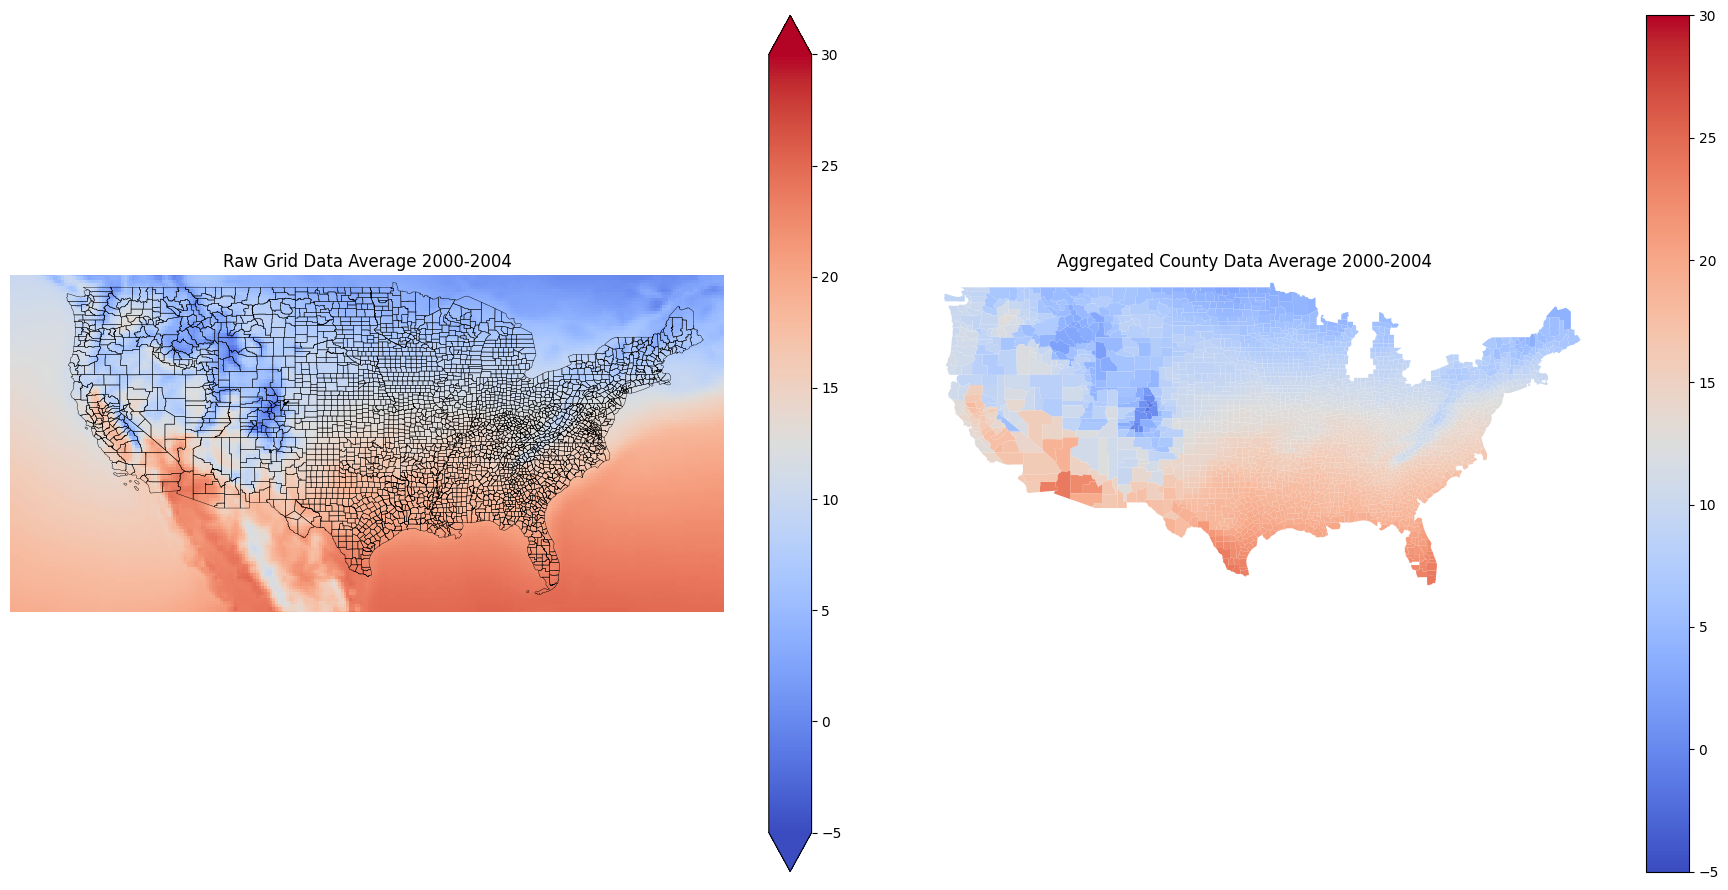

Done!


In [38]:
check_aggregation_correctness(
    raw_folder="/global/scratch/users/yougsanghvi/gdnat_tiff_files_by_yr",
    agg_folder="/global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa",
    raw_template="gdnat_{}.tif",
    agg_template="gdnat_usa_agg_{}.csv",
    shapefile_path="/global/scratch/users/yougsanghvi/shapefiles/tl_2016_us_county_mortality.shp",
    shapefile_id_col="GEOID",
    years=range(2000, 2005)
)


[1/4] Loading shapefile...


[2/4] Checking CSVs for NA counties...
[3/4] Found 97 unique counties with NAs
[4/4] Plotting NA counties...


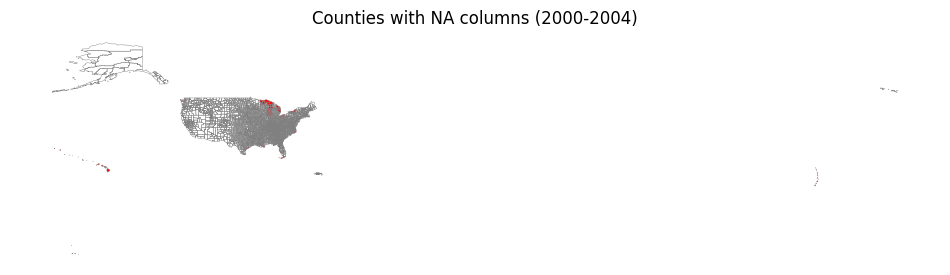

{'12015',
 '12045',
 '12075',
 '12087',
 '12089',
 '13039',
 '13127',
 '13179',
 '13191',
 '15001',
 '15003',
 '15007',
 '17031',
 '17097',
 '2013',
 '2016',
 '2050',
 '2070',
 '2122',
 '2130',
 '2150',
 '2158',
 '2164',
 '2180',
 '2185',
 '2188',
 '2201',
 '22075',
 '2220',
 '2231',
 '2261',
 '26001',
 '26003',
 '26005',
 '26007',
 '26019',
 '26021',
 '26041',
 '26053',
 '26061',
 '26063',
 '26069',
 '26083',
 '26089',
 '26095',
 '26101',
 '26103',
 '26105',
 '26121',
 '26127',
 '26131',
 '26139',
 '26141',
 '26151',
 '26153',
 '26159',
 '27031',
 '36011',
 '36045',
 '36055',
 '36075',
 '36117',
 '37031',
 '37095',
 '37141',
 '39007',
 '39035',
 '39043',
 '39085',
 '39093',
 '44005',
 '48321',
 '53031',
 '55003',
 '55029',
 '55059',
 '55061',
 '55071',
 '55079',
 '55089',
 '55101',
 '55117',
 '60020',
 '60030',
 '60040',
 '6015',
 '6037',
 '6075',
 '6083',
 '6111',
 '66010',
 '69085',
 '69100',
 '69110',
 '69120',
 '72097',
 '78010'}

In [ ]:
plot_na_counties(
    agg_folder="/global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa",
    agg_template="gdnat_usa_agg_{}.csv",
    shapefile_path="/global/scratch/users/yougsanghvi/shapefiles/tl_2016_us_county_mortality.shp",
    shapefile_id_col="GEOID",
    years=range(2000, 2005),
    crop_bounds=(-130, 20, -60, 60)  # mainland USA approx bounds
)


[1/4] Loading shapefile...
[2/4] Checking CSVs for NA counties...
[3/4] Found 97 unique counties with NAs in 'order_' columns.
[4/4] Plotting NA counties...


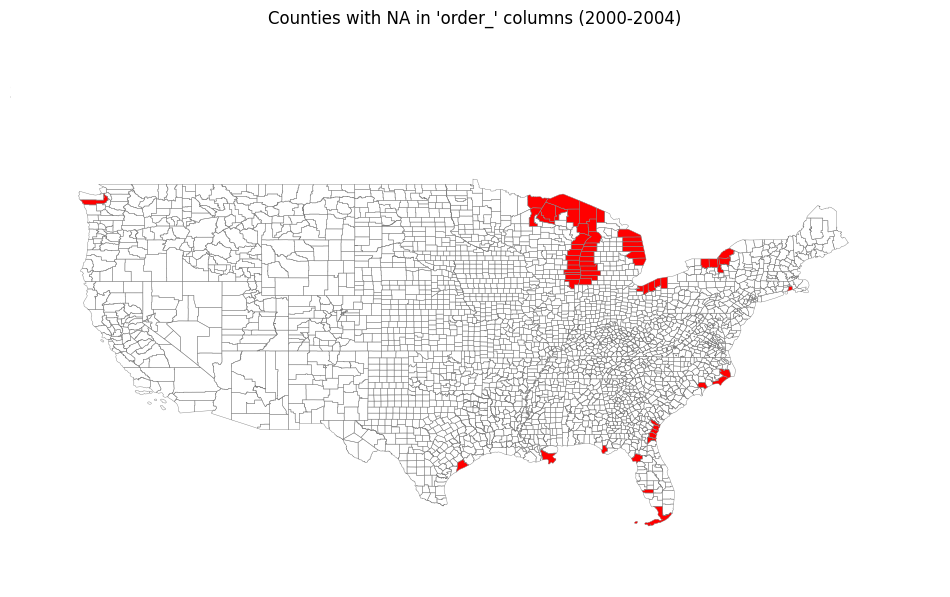

In [12]:
na_fips = plot_na_counties(
    agg_folder="/global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa",
    agg_template="gdnat_usa_agg_{}.csv",
    shapefile_path="/global/scratch/users/yougsanghvi/shapefiles/tl_2016_us_county_mortality.shp",
    shapefile_id_col="GEOID",
    years=range(2000, 2005),
    crop_bounds=(-130, 20, -60, 60)  # mainland USA approx bounds
)


In [41]:
na_fips

{'12015',
 '12045',
 '12075',
 '12087',
 '12089',
 '13039',
 '13127',
 '13179',
 '13191',
 '15001',
 '15003',
 '15007',
 '17031',
 '17097',
 '2013',
 '2016',
 '2050',
 '2070',
 '2122',
 '2130',
 '2150',
 '2158',
 '2164',
 '2180',
 '2185',
 '2188',
 '2201',
 '22075',
 '2220',
 '2231',
 '2261',
 '26001',
 '26003',
 '26005',
 '26007',
 '26019',
 '26021',
 '26041',
 '26053',
 '26061',
 '26063',
 '26069',
 '26083',
 '26089',
 '26095',
 '26101',
 '26103',
 '26105',
 '26121',
 '26127',
 '26131',
 '26139',
 '26141',
 '26151',
 '26153',
 '26159',
 '27031',
 '36011',
 '36045',
 '36055',
 '36075',
 '36117',
 '37031',
 '37095',
 '37141',
 '39007',
 '39035',
 '39043',
 '39085',
 '39093',
 '44005',
 '48321',
 '53031',
 '55003',
 '55029',
 '55059',
 '55061',
 '55071',
 '55079',
 '55089',
 '55101',
 '55117',
 '60020',
 '60030',
 '60040',
 '6015',
 '6037',
 '6075',
 '6083',
 '6111',
 '66010',
 '69085',
 '69100',
 '69110',
 '69120',
 '72097',
 '78010'}

[1/4] Loading shapefile...
[2/4] Checking CSVs for NA counties...
[3/4] Found 99 unique counties with NAs in 'order_' columns.
[4/4] Plotting NA counties...


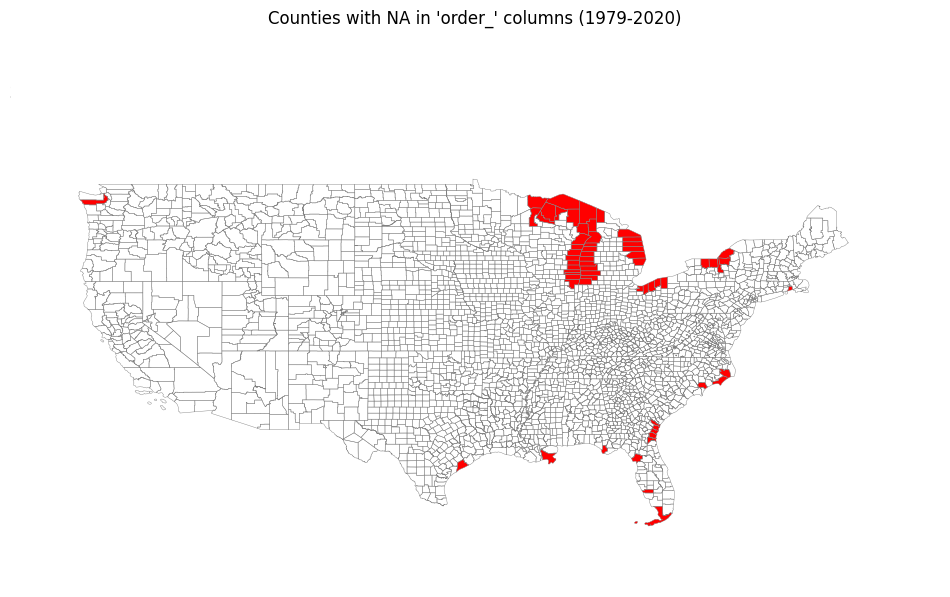

In [13]:
na_fips = plot_na_counties(
    agg_folder="/global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa",
    agg_template="gdnat_usa_agg_{}.csv",
    shapefile_path="/global/scratch/users/yougsanghvi/shapefiles/tl_2016_us_county_mortality.shp",
    shapefile_id_col="GEOID",
    years=range(1979, 2021),
    crop_bounds=(-130, 20, -60, 60)  # mainland USA approx bounds
)

### Diff Checks


=== Plotting difference for model: MIROC6 ===
[1/8] Loading shapefile...
[2/8] Loading first county-level dataset...
[3/8] Loading second county-level dataset...
[4/8] Validating column names...
[5/8] Processing first dataset...
Filtering data between 2000 and 2004 on column 'year'...
[6/8] Processing second dataset...
Filtering data between 2000 and 2004 on column 'year'...
[7/8] Calculating difference and merging with shapefile....
[8/8] Plotting difference map...
Done.


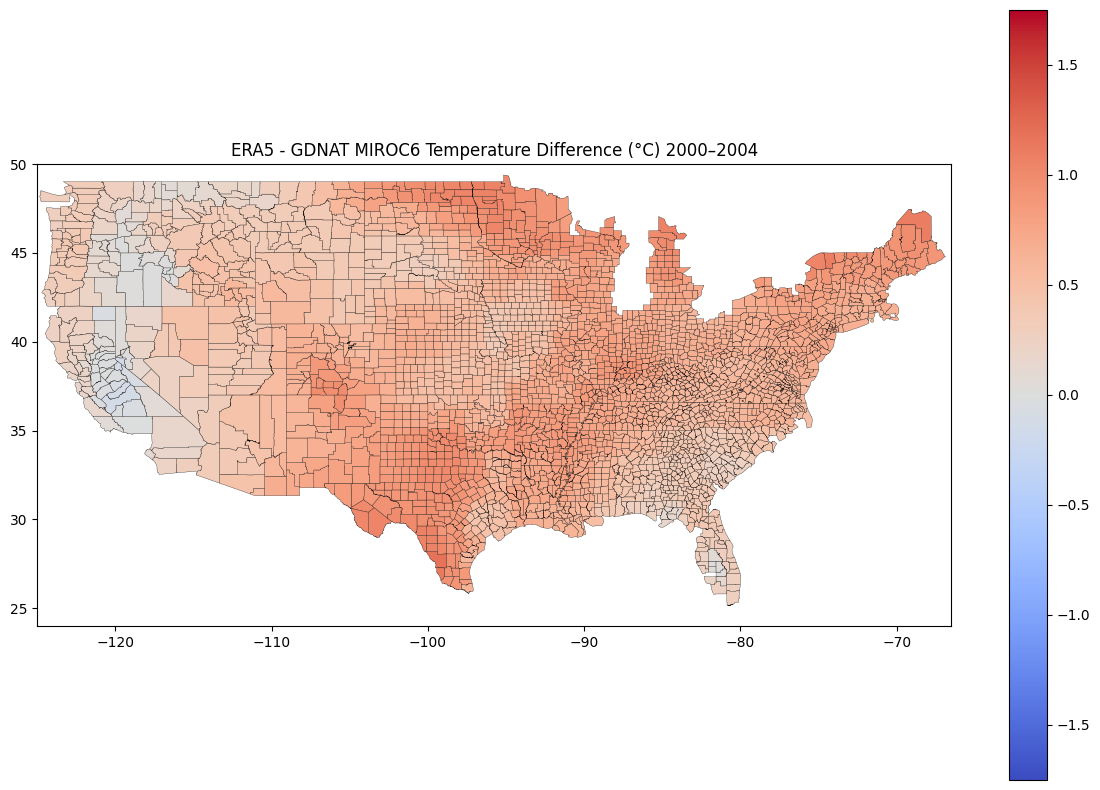


=== Plotting difference for model: ACCESS-ESM1-5 ===
[1/8] Loading shapefile...
[2/8] Loading first county-level dataset...
[3/8] Loading second county-level dataset...
[4/8] Validating column names...
[5/8] Processing first dataset...
Filtering data between 2000 and 2004 on column 'year'...
[6/8] Processing second dataset...
Filtering data between 2000 and 2004 on column 'year'...
[7/8] Calculating difference and merging with shapefile....
[8/8] Plotting difference map...
Done.


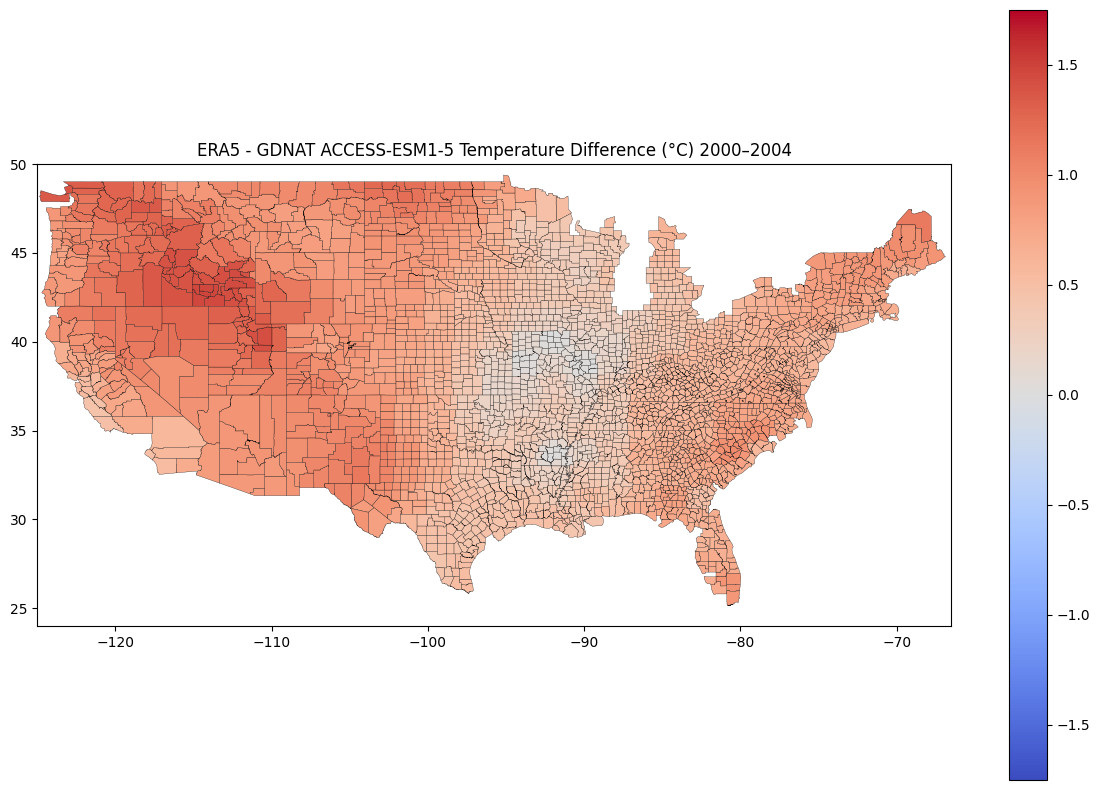


=== Plotting difference for model: CanESM5 ===
[1/8] Loading shapefile...
[2/8] Loading first county-level dataset...
[3/8] Loading second county-level dataset...
[4/8] Validating column names...
[5/8] Processing first dataset...
Filtering data between 2000 and 2004 on column 'year'...
[6/8] Processing second dataset...
Filtering data between 2000 and 2004 on column 'year'...
[7/8] Calculating difference and merging with shapefile....
[8/8] Plotting difference map...
Done.


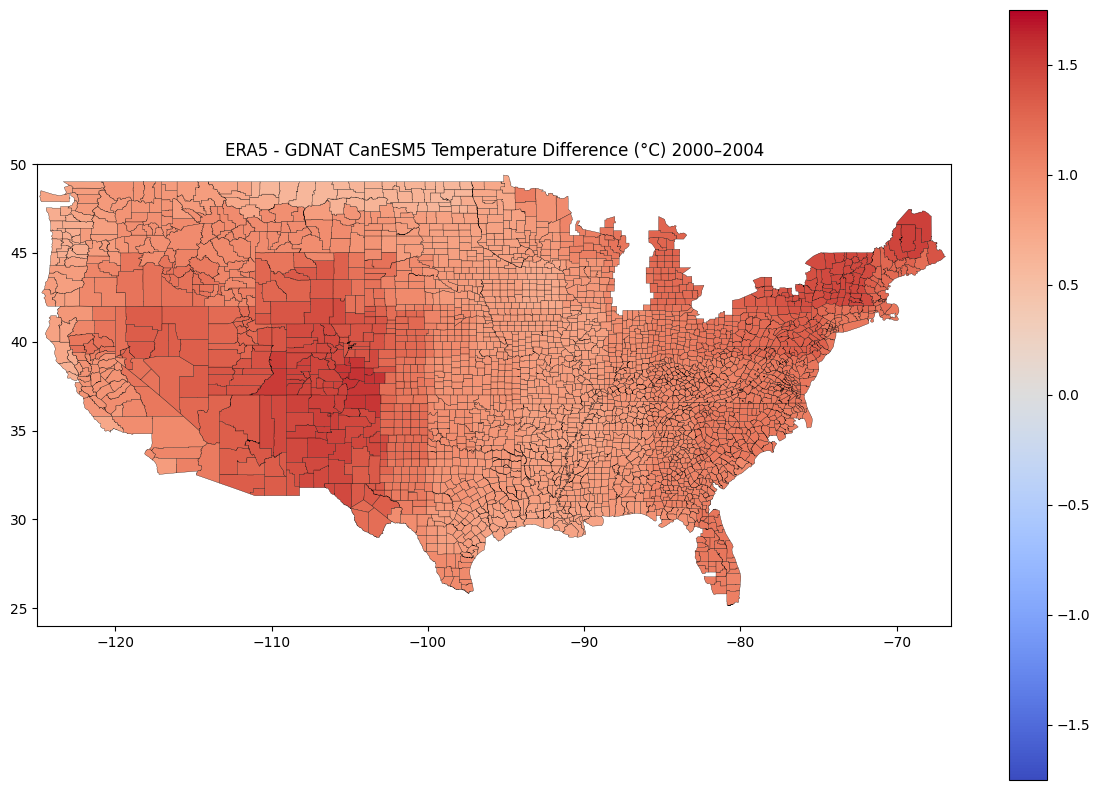


=== Plotting difference for model: MRI-ESM2-0 ===
[1/8] Loading shapefile...
[2/8] Loading first county-level dataset...
[3/8] Loading second county-level dataset...
[4/8] Validating column names...
[5/8] Processing first dataset...
Filtering data between 2000 and 2004 on column 'year'...
[6/8] Processing second dataset...
Filtering data between 2000 and 2004 on column 'year'...
[7/8] Calculating difference and merging with shapefile....
[8/8] Plotting difference map...
Done.


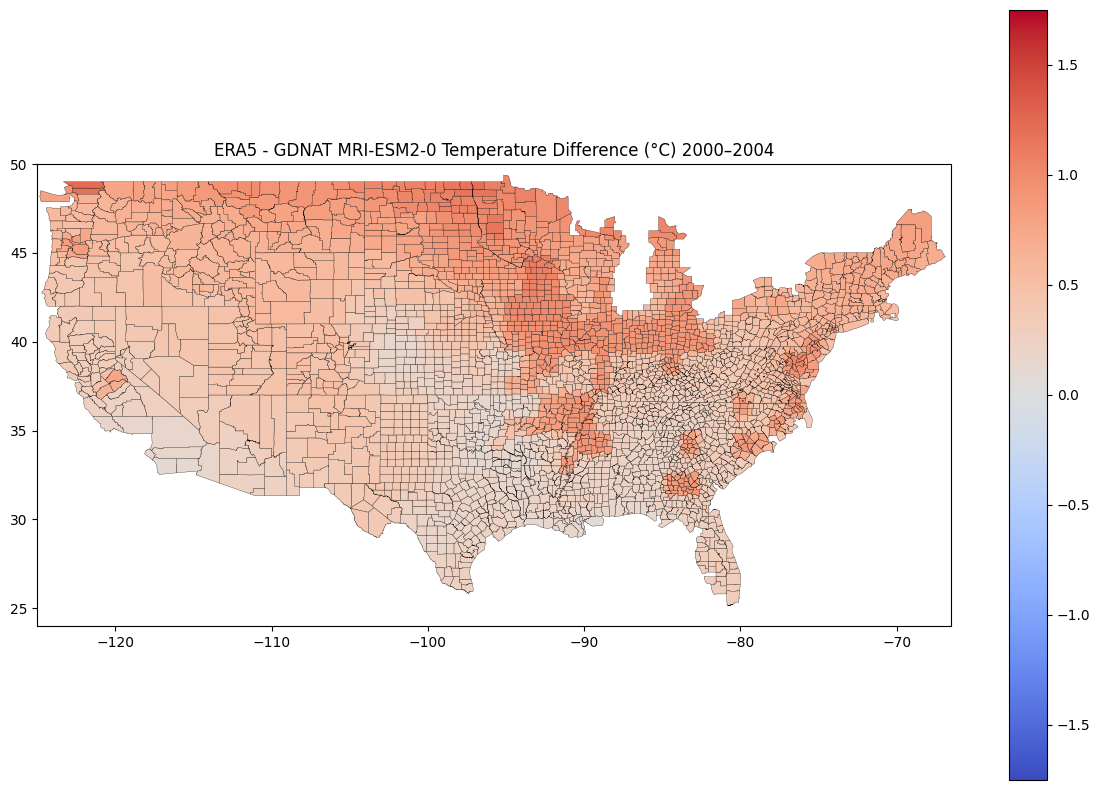


=== Plotting difference for model: NorESM2-LM ===
[1/8] Loading shapefile...
[2/8] Loading first county-level dataset...
[3/8] Loading second county-level dataset...
[4/8] Validating column names...
[5/8] Processing first dataset...
Filtering data between 2000 and 2004 on column 'year'...
[6/8] Processing second dataset...
Filtering data between 2000 and 2004 on column 'year'...
[7/8] Calculating difference and merging with shapefile....
[8/8] Plotting difference map...
Done.


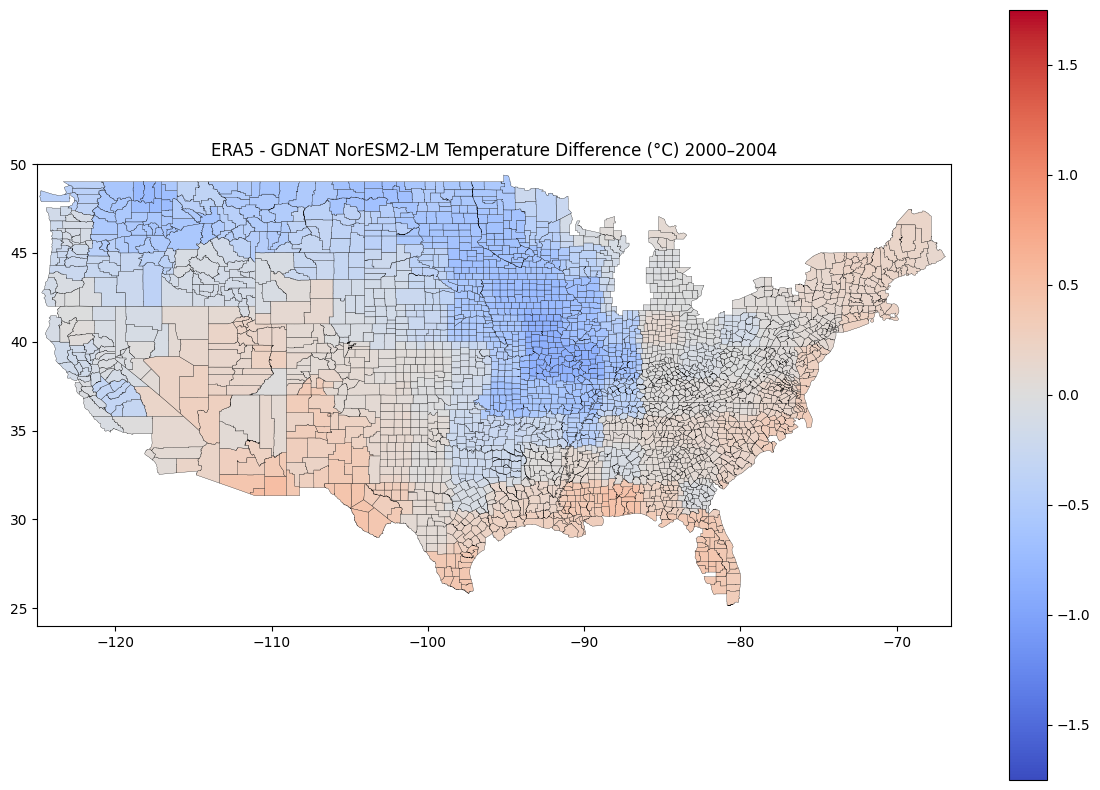


=== Plotting difference for model: ACCESS-CM2 ===
[1/8] Loading shapefile...
[2/8] Loading first county-level dataset...
[3/8] Loading second county-level dataset...
[4/8] Validating column names...
[5/8] Processing first dataset...
Filtering data between 2000 and 2004 on column 'year'...
[6/8] Processing second dataset...
Filtering data between 2000 and 2004 on column 'year'...
[7/8] Calculating difference and merging with shapefile....
[8/8] Plotting difference map...
Done.


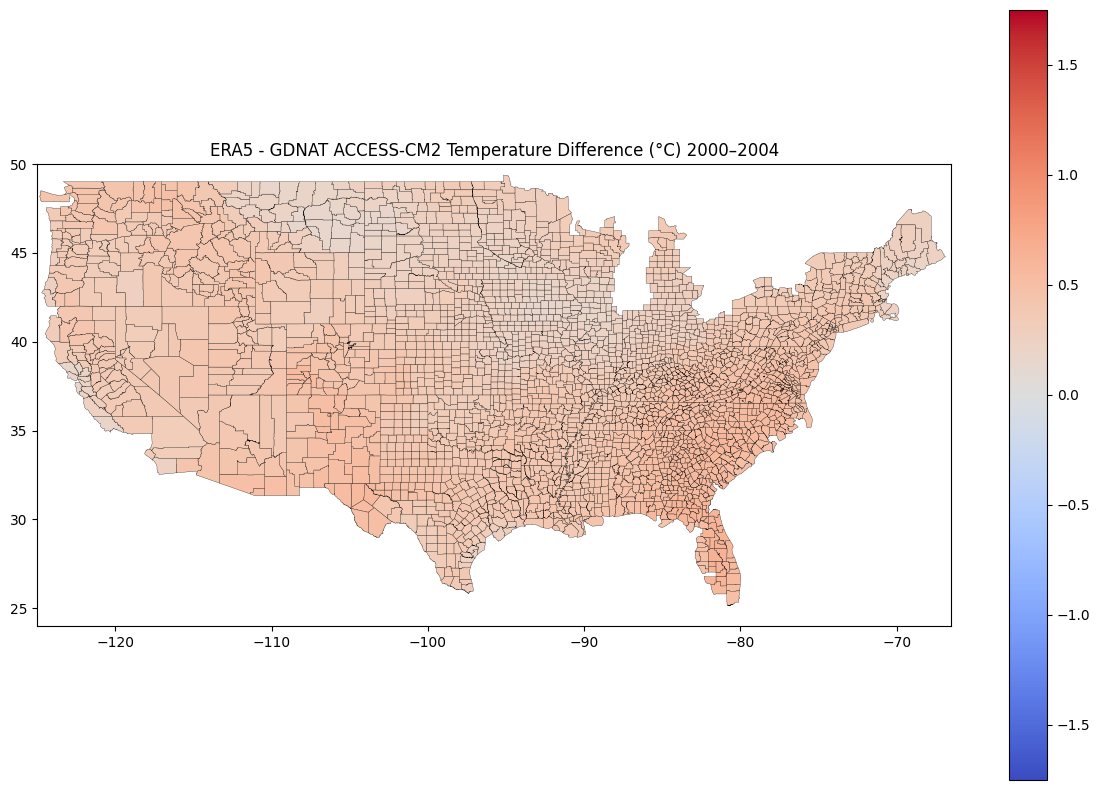

In [6]:
gdnat_models = ["MIROC6", "ACCESS-ESM1-5", "CanESM5", "MRI-ESM2-0", "NorESM2-LM", "ACCESS-CM2"]

for model in gdnat_models:
    print(f"\n=== Plotting difference for model: {model} ===")
    
    functions.plot_county_diff(
        shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
        shapefile_id_col="GEOID",

        # Dataset 1: ERA5
        county_data_path_1=os.path.join(config.ERA5_AGG_FOLDER, "era5_usa_agg_1979_2004.csv"),
        county_id_col_1="poly_id",
        value_col1="order_1_avg",
        separate_files_by_year_1=False,

        # Dataset 2: GDNat
        county_data_path_2=os.path.join(config.GDNAT_USA_AGG_ALL_MODELS_FP, model, f"gdnat_usa_agg_{model}_1979_2004.csv"),
        county_id_col_2="poly_id",
        value_col2="order_1_avg",
        separate_files_by_year_2=False,

        years=range(2000, 2005),
        time_col="year",

        vmin=-1.75,
        vmax=1.75,
        crop_bounds=(-125, -66.5, 24, 50),

        title=f"ERA5 - GDNAT {model} Temperature Difference (°C) 2000–2004"
    )
